# AMOC Publication Figures

This notebook demonstrates how to create publication-quality AMOC figures using the AMOCatlas package with PyGMT.
It reproduces plots similar to those in Frajka-Williams et al. (2019, 2023) and other AMOC publications.

**Features:**
- Clean, simplified workflow using amocatlas module functions
- Publication-quality PyGMT plots
- Multi-array time series comparison
- Tukey filtering for low-frequency analysis
- Component breakdown plots (e.g., RAPID, OSNAP)

Figures are designed to be re-used: the "AMOCatlas" badge and timestamp can be cropped out.

Suggested citation:
- For the multi-panel figure, you can say "updated from Frajka-Williams et al. 2019".  


In [1]:
import os

# AMOCatlas imports
from amocatlas import read, tools, plotters

# Set GMT library path if needed (adjust for your system)
# os.environ["GMT_LIBRARY_PATH"] = "/opt/homebrew/lib"  # macOS Homebrew
# os.environ["GMT_LIBRARY_PATH"] = "/usr/lib"          # Linux

# Create figures directory for documentation
figures_dir = "../docs/source/_static/paperfigs"
os.makedirs(figures_dir, exist_ok=True)
print(f"✓ Figures will be saved to: {figures_dir}/")

✓ Figures will be saved to: ../docs/source/_static/paperfigs/


## 1. Load and Standardize Data

Load MOC data from all major observing arrays and convert to standardized format.

In [2]:
# Load datasets
print("Loading AMOC array datasets...")

# RAPID 26°N
rapid_std = read.rapid(all_files=True)

# MOVE 16°N
move_std = read.move()

# OSNAP Subpolar
osnap_std = read.osnap(transport_only=True)

# SAMBA 34.5°S
samba_std = read.samba(all_files=True)

print("✓ All datasets loaded and standardized")

rapid_mht = rapid_std[4]

Loading AMOC array datasets...
Loading 5 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series
  1. moc_vertical.nc: RAPID vertical streamfunction time series
  2. ts_gridded.nc: RAPID gridded temperature and salinity
  3. 2d_gridded.nc: RAPID 2D gridded data
  4. meridional_transports.nc: RAPID meridional transport data

Loading 1 MOVE 16°N dataset(s):
  0. OS_MOVE_20000206-20221014_DPR_VOLUMETRANSPORT.nc: MOVE transport time series

Loading 1 OSNAP dataset(s):
  0. OSNAP_MOC_MHT_MFT_TimeSeries_201408_202207_2025.nc: Time series of MOC, MHT, and MFT (2014-2022)

Loading 2 SAMBA 34.5°S dataset(s):
  0. Upper_Abyssal_Transport_Anomalies.txt: Daily volume transport anomaly estimates for the upper and abyssal cells of the MOC
  1. MOC_TotalAnomaly_and_constituents.asc: Daily travel time values, calibrated to a nominal pressure of 1000 dbar, and bottom pressures from the two PIES/CPIES moorings



KeyboardInterrupt: 

In [3]:
# RAPID 26°N
rapid_std = read.rapid(all_files=True)
ts_gridded = rapid_std[2]

ts_gridded

Loading 5 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series
  1. moc_vertical.nc: RAPID vertical streamfunction time series
  2. ts_gridded.nc: RAPID gridded temperature and salinity
  3. 2d_gridded.nc: RAPID 2D gridded data
  4. meridional_transports.nc: RAPID meridional transport data



<xarray.Dataset> Size: 509MB
Dimensions:            (depth: 242, TIME: 14599)
Coordinates:
  * TIME               (TIME) datetime64[ns] 117kB 2004-04-02 ... 2024-03-27
    PRESSURE           (depth) float64 2kB ...
Dimensions without coordinates: depth
Data variables: (12/18)
    TEMP_WEST          (depth, TIME) float64 28MB ...
    PSAL_WEST          (depth, TIME) float64 28MB ...
    TEMP_WB3           (depth, TIME) float64 28MB ...
    PSAL_WB3           (depth, TIME) float64 28MB ...
    TEMP_EAST          (depth, TIME) float64 28MB ...
    PSAL_EAST          (depth, TIME) float64 28MB ...
    ...                 ...
    TEMP_EAST_FLAG     (depth, TIME) float64 28MB ...
    PSAL_EAST_FLAG     (depth, TIME) float64 28MB ...
    TEMP_MARWEST_FLAG  (depth, TIME) float64 28MB ...
    PSAL_MARWEST_FLAG  (depth, TIME) float64 28MB ...
    TEMP_MAREAST_FLAG  (depth, TIME) float64 28MB ...
    PSAL_MAREAST_FLAG  (depth, TIME) float64 28MB ...
Attributes: (12/40)
    title:                                 RAPID streamfunction
    summary:                               RAPID 26N transport estimates dataset
    description:                           RAPID 26N transport estimates dataset
    program:                               RAPID
    project:                               RAPID-AMOC 26°N array
    license:                               UK Open Government Licence v3.0 ht...
    ...                                    ...
    variable_mapping:                      {'time': 'TIME', 'TG_west': 'TEMP_...
    original_variable_metadata:            {'TG_west': {'long_name': 'Tempera...
    applied_variable_mapping:              {'time': 'TIME', 'TG_west': 'TEMP_...
    version:                               v2024.1a
    files:                                 {'moc_transports.nc': {'featureTyp...
    convert_to_coord:                      pressure

(242, 240)


/Users/eddifying/Cloudfree/github/AMOCatlas/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/eddifying/Cloudfree/github/AMOCatlas/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/eddifying/Cloudfree/github/AMOCatlas/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


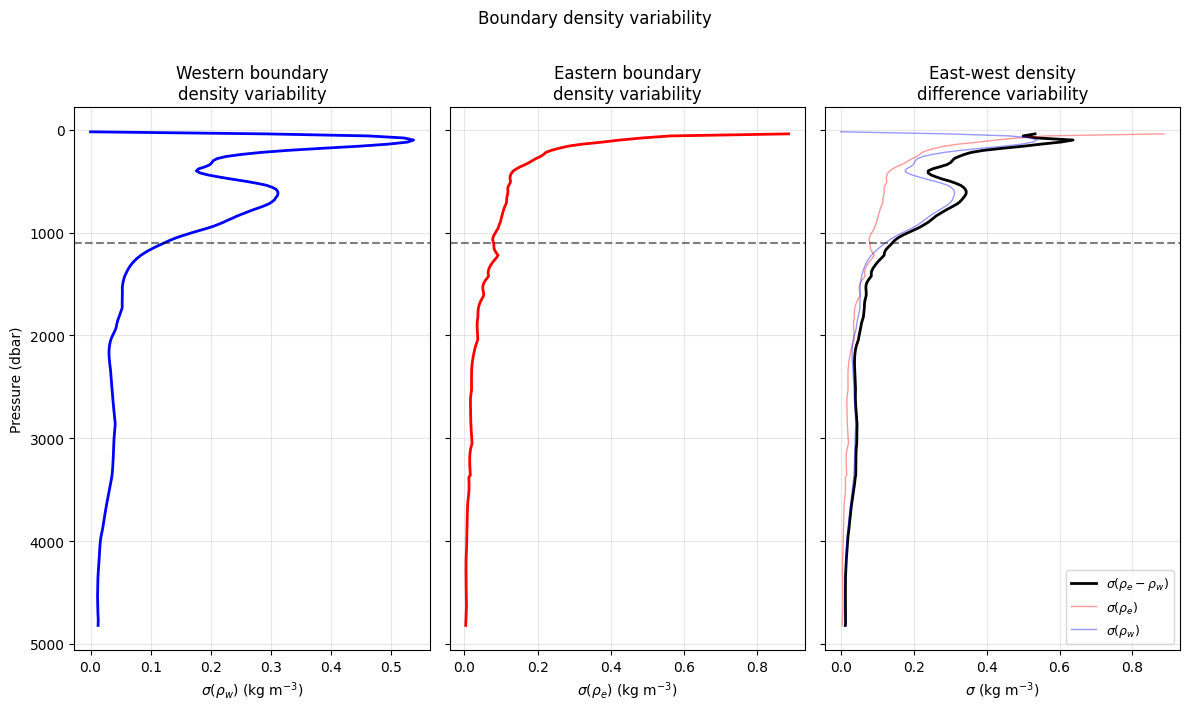

(242,)
(242,)


/Users/eddifying/Cloudfree/github/AMOCatlas/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/eddifying/Cloudfree/github/AMOCatlas/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/eddifying/Cloudfree/github/AMOCatlas/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [37]:
import gsw
import numpy as np
import matplotlib.pyplot as plt

# ---- Density calculations ----
DENS_WEST = gsw.rho(ts_gridded["TEMP_WEST"], ts_gridded["PSAL_WEST"], 0)
DENS_EAST = gsw.rho(ts_gridded["TEMP_EAST"], ts_gridded["PSAL_EAST"], 0)
DENS_ANOMALY = DENS_EAST - DENS_WEST  # (depth, time)
# ---- Resample to monthly means first ----
DENS_WEST_monthly = DENS_WEST.resample(TIME="1ME").mean()
DENS_EAST_monthly = DENS_EAST.resample(TIME="1ME").mean()

# ---- Remove seasonal cycle via groupby ----
# ---- Remove seasonal cycle via groupby ----
DENS_WEST_ds = (
    DENS_WEST_monthly.groupby("TIME.month")
    - DENS_WEST_monthly.groupby("TIME.month").mean()
)
DENS_EAST_ds = (
    DENS_EAST_monthly.groupby("TIME.month")
    - DENS_EAST_monthly.groupby("TIME.month").mean()
)
DENS_ANOMALY_ds = DENS_EAST_ds - DENS_WEST_ds

# Check
print(DENS_WEST_ds.shape)  # should be (242, n_months_total)

# ---- Recompute std along time dimension ----
dens_west_std = DENS_WEST_ds.std(dim="TIME", ddof=0).values
dens_east_std = DENS_EAST_ds.std(dim="TIME", ddof=0).values
dens_diff_std = DENS_ANOMALY_ds.std(dim="TIME", ddof=0).values

# ---- Plot ----
fig, axes = plt.subplots(1, 3, figsize=(12, 7), sharey=True)

ax = axes[0]
ax.plot(dens_west_std, depths, "b-", lw=2)
ax.set_xlabel(r"$\sigma(\rho_w)$ (kg m$^{-3}$)")
ax.set_ylabel("Pressure (dbar)")
ax.set_title("Western boundary\ndensity variability")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(dens_east_std, depths, "r-", lw=2)
ax.set_xlabel(r"$\sigma(\rho_e)$ (kg m$^{-3}$)")
ax.set_title("Eastern boundary\ndensity variability")
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(dens_diff_std, depths, "k-", lw=2, label=r"$\sigma(\rho_e - \rho_w)$")
ax.plot(dens_east_std, depths, "r-", lw=1, alpha=0.4, label=r"$\sigma(\rho_e)$")
ax.plot(dens_west_std, depths, "b-", lw=1, alpha=0.4, label=r"$\sigma(\rho_w)$")
ax.set_xlabel(r"$\sigma$ (kg m$^{-3}$)")
ax.set_title("East-west density\ndifference variability")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

for ax in axes:
    ax.invert_yaxis()
    ax.axhline(z_moc, color="k", ls="--", alpha=0.5, label="1100 dbar")

plt.suptitle("Boundary density variability", y=1.01)
plt.tight_layout()
plt.show()

dens_west_std = DENS_WEST_ds.std(dim="TIME").values  # (242,)
dens_east_std = DENS_EAST_ds.std(dim="TIME").values
dens_diff_std = DENS_ANOMALY_ds.std(dim="TIME").values
depths = ts_gridded["PRESSURE"].values  # (242,)

print(dens_west_std.shape)  # should be (242,)
print(depths.shape)  # should be (242,)

g/(rho_0*f) = 102.71 m^4 kg^-1 s
Typical density anomaly std: 0.1266 kg/m^3
Max upper cumulative: 205432 kg m^-1 dbar
Upper limb MOC estimate: 21.1 Sv
Lower limb MOC estimate: 63.1 Sv


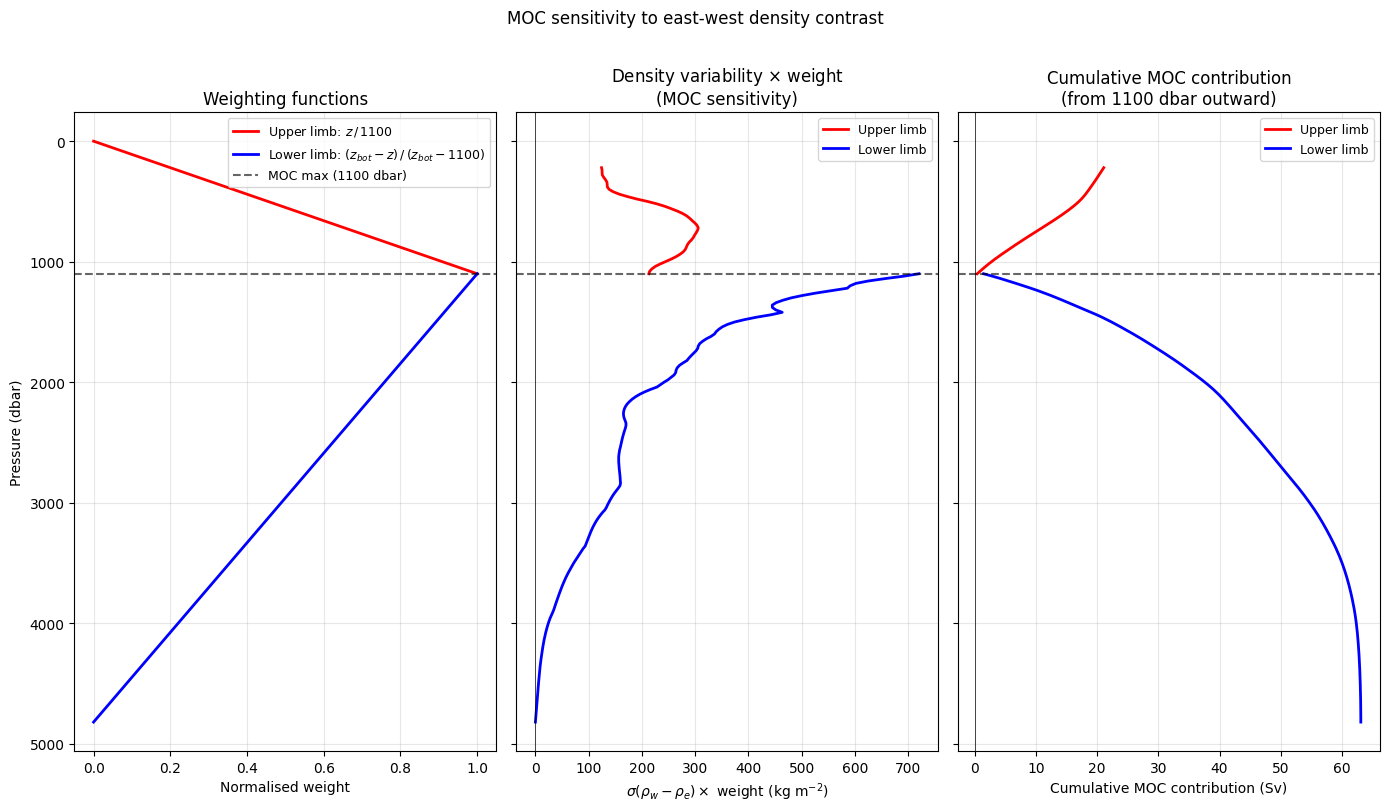

Uncorrected lower limb: 63.1 Sv
Uncorrected upper limb: 21.1 Sv
Barotropic compensation needed: 42.0 Sv


In [31]:
import matplotlib.pyplot as plt

# ---- Constants ----
g = 9.81
rho_0 = 1027.0
f = 9.3e-5  # Coriolis at 26N
sverdrup = 1e6
z_moc = 1100.0  # depth of max overturning in dbar

# ---- Ensure numpy arrays ----
depths = np.array(ts_gridded["PRESSURE"])  # (depth,)
dens_anomaly_np = np.array(DENS_WEST - DENS_EAST)  # (depth, time)
dens_anomaly_std = np.std(dens_anomaly_np, axis=1)  # (depth,)

# ---- Depth spacing (dbar, ~= m) ----
dz = np.abs(np.gradient(depths))

# ---- Masks ----
z_bot = depths.max()
upper_mask = depths <= z_moc
lower_mask = depths >= z_moc
upper_idx = np.where(upper_mask)[0]
lower_idx = np.where(lower_mask)[0]

# ---- Unnormalised weights (for MOC calculation) ----
upper_weights = np.where(upper_mask, depths, np.nan)  # 0 at surface, 1100 at z_moc
lower_weights = np.where(
    lower_mask, z_bot - depths, np.nan
)  # z_bot-z_moc at z_moc, 0 at bottom

# ---- Normalised weights (for plotting panel 1) ----
upper_weights_norm = np.where(upper_mask, depths / z_moc, np.nan)
lower_weights_norm = np.where(lower_mask, (z_bot - depths) / (z_bot - z_moc), np.nan)

# ---- Weighted density std (panel 2) ----
weighted_upper = np.where(upper_mask, dens_anomaly_std * upper_weights, np.nan)
weighted_lower = np.where(lower_mask, dens_anomaly_std * lower_weights, np.nan)

# ---- Cumulative integrals outward from z_moc (units: kg/m * dbar^2) ----
cumul_upper = np.full(len(depths), np.nan)
cumul_lower = np.full(len(depths), np.nan)

# Upper: accumulate from z_moc toward surface
cumul_upper[upper_idx] = np.cumsum((weighted_upper[upper_idx] * dz[upper_idx])[::-1])[
    ::-1
]

# Lower: accumulate from z_moc toward bottom
cumul_lower[lower_idx] = np.cumsum(weighted_lower[lower_idx] * dz[lower_idx])

# ---- Prefactor: g/(rho_0*f), dbar->m conversion (1 dbar = 1 m), /1e6 for Sv ----
# weights and dz are both in dbar ~ m, so units are kg/m^3 * m * m = kg/m
# then g/(rho_0*f) has units m^4/(kg s^-1) -> m^3/s -> /1e6 for Sv
prefactor = (g / (rho_0 * f)) / sverdrup

# ---- Sanity checks ----
print(f"g/(rho_0*f) = {g / (rho_0 * f):.2f} m^4 kg^-1 s")
print(f"Typical density anomaly std: {np.nanmean(np.abs(dens_anomaly_std)):.4f} kg/m^3")
print(f"Max upper cumulative: {np.nanmax(cumul_upper):.0f} kg m^-1 dbar")
print(f"Upper limb MOC estimate: {prefactor * np.nanmax(cumul_upper):.1f} Sv")
print(f"Lower limb MOC estimate: {prefactor * np.nanmax(cumul_lower):.1f} Sv")

# ---- Plot ----
fig, axes = plt.subplots(1, 3, figsize=(14, 8), sharey=True)

ax = axes[0]
ax.plot(upper_weights_norm, depths, "r-", lw=2, label=r"Upper limb: $z\, /\, 1100$")
ax.plot(
    lower_weights_norm,
    depths,
    "b-",
    lw=2,
    label=r"Lower limb: $(z_{bot} - z)\, /\, (z_{bot} - 1100)$",
)
ax.axhline(z_moc, color="k", ls="--", alpha=0.6, label="MOC max (1100 dbar)")
ax.set_xlabel("Normalised weight")
ax.set_ylabel("Pressure (dbar)")
ax.set_title("Weighting functions")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(weighted_upper, depths, "r-", lw=2, label="Upper limb")
ax.plot(weighted_lower, depths, "b-", lw=2, label="Lower limb")
ax.axhline(z_moc, color="k", ls="--", alpha=0.6)
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel(r"$\sigma(\rho_w - \rho_e) \times$ weight (kg m$^{-2}$)")
ax.set_title("Density variability $\\times$ weight\n(MOC sensitivity)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(cumul_upper * prefactor, depths, "r-", lw=2, label="Upper limb")
ax.plot(cumul_lower * prefactor, depths, "b-", lw=2, label="Lower limb")
ax.axhline(z_moc, color="k", ls="--", alpha=0.6)
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("Cumulative MOC contribution (Sv)")
ax.set_title("Cumulative MOC contribution\n(from 1100 dbar outward)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

for ax in axes:
    ax.invert_yaxis()

plt.suptitle("MOC sensitivity to east-west density contrast", y=1.01)
plt.tight_layout()
plt.show()

# The compensation needed to make lower limb = upper limb
delta_psi = (prefactor * np.nanmax(cumul_lower)) - (prefactor * np.nanmax(cumul_upper))
print(f"Uncorrected lower limb: {prefactor * np.nanmax(cumul_lower):.1f} Sv")
print(f"Uncorrected upper limb: {prefactor * np.nanmax(cumul_upper):.1f} Sv")
print(f"Barotropic compensation needed: {delta_psi:.1f} Sv")
# This should be ~45 Sv, carried by v_ref

/Users/eddifying/Cloudfree/github/AMOCatlas/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/eddifying/Cloudfree/github/AMOCatlas/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/eddifying/Cloudfree/github/AMOCatlas/venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


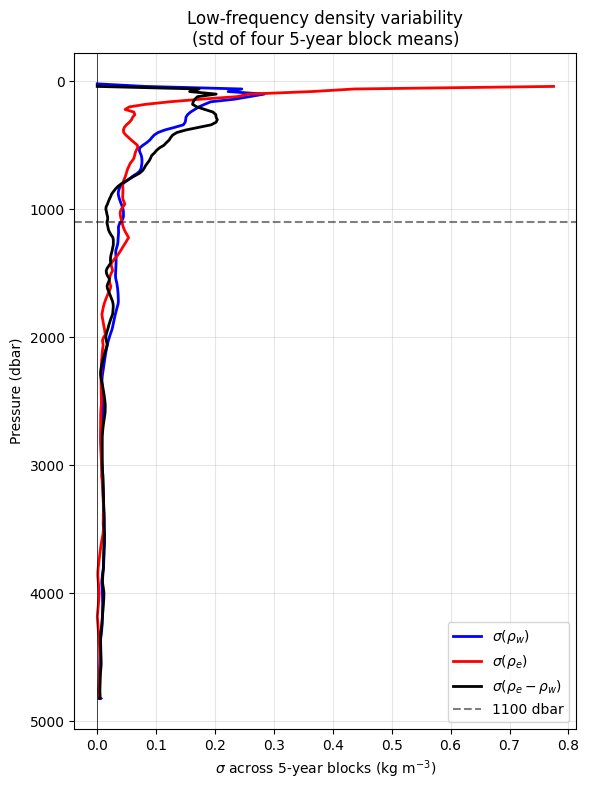

/var/folders/t1/z5bp59k95119nw35yqv699t40000gn/T/ipykernel_14140/73591957.py:71: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(weighted_upper_west, depths, 'b-', lw=1.5, ls='--', label='Upper limb west')
/var/folders/t1/z5bp59k95119nw35yqv699t40000gn/T/ipykernel_14140/73591957.py:72: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(weighted_upper_east, depths, 'r-', lw=1.5, ls='--', label='Upper limb east')
/var/folders/t1/z5bp59k95119nw35yqv699t40000gn/T/ipykernel_14140/73591957.py:73: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(weighted_lower_west, depths, 'b-', lw=1.5, ls=':',  label='Lower l

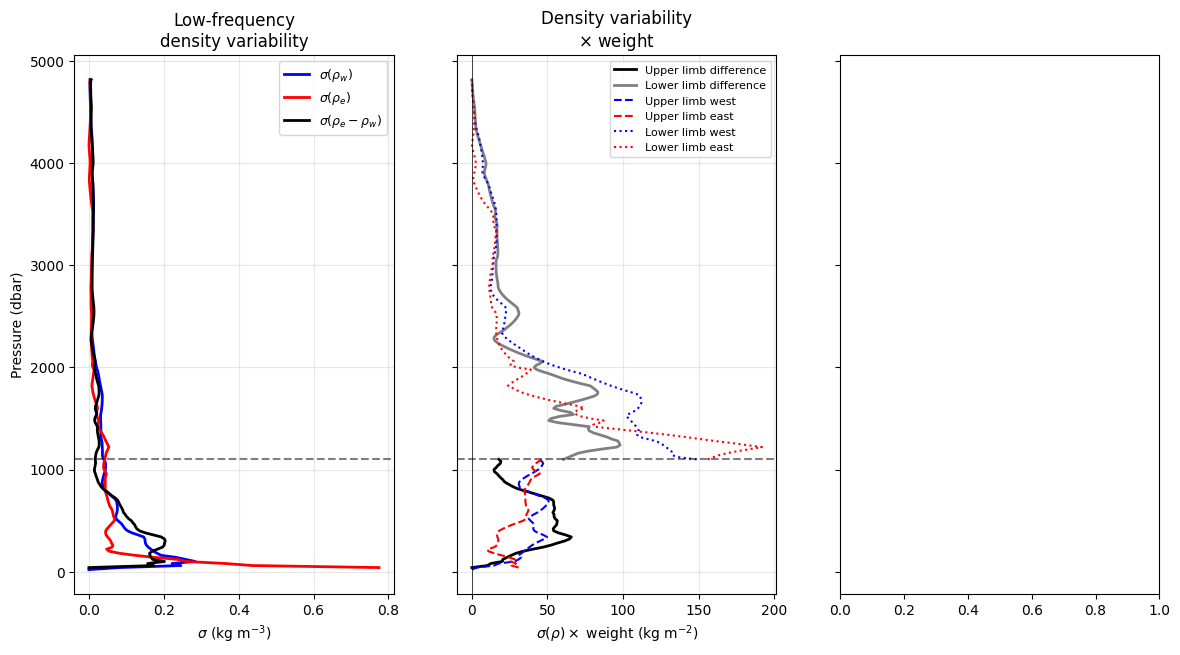

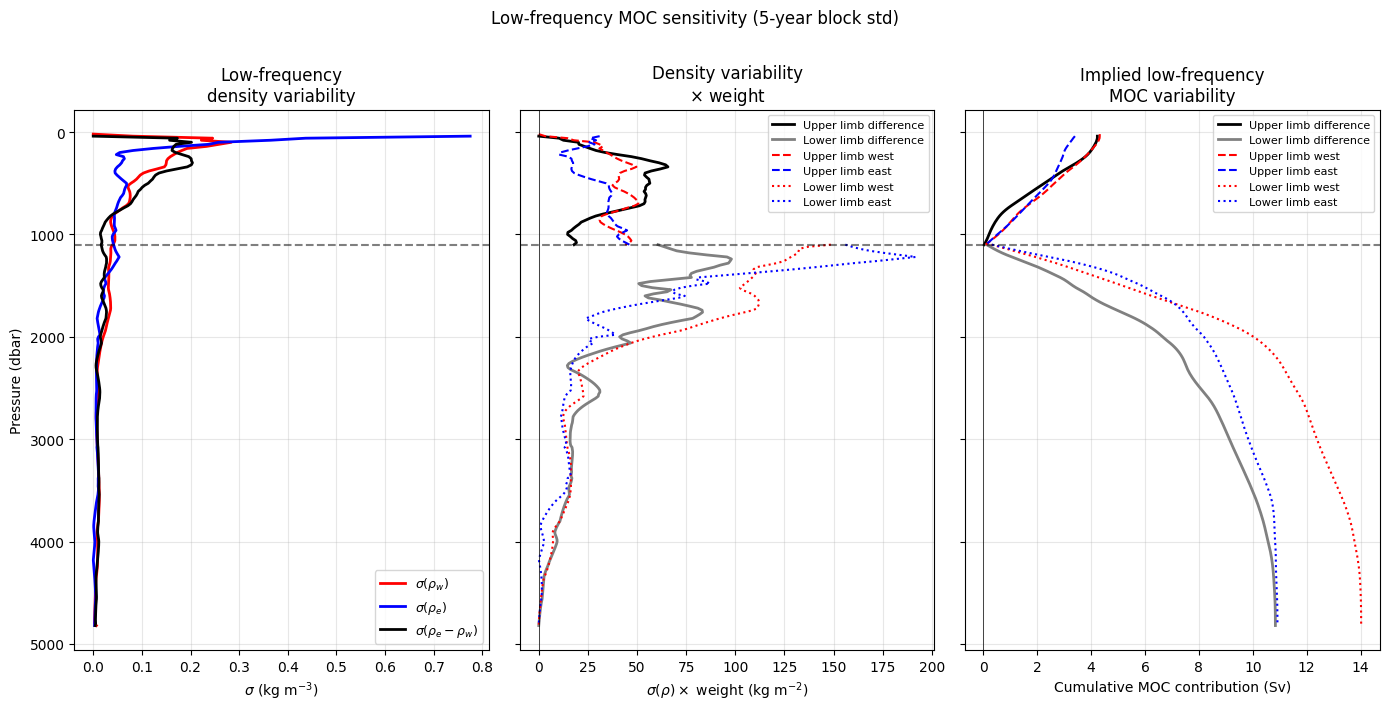

In [43]:
# ---- 5-year block means ----
DENS_WEST_5yr = DENS_WEST_ds.resample(TIME="5YE").mean()  # (242, 4)
DENS_EAST_5yr = DENS_EAST_ds.resample(TIME="5YE").mean()  # (242, 4)
DENS_ANOMALY_5yr = DENS_EAST_5yr - DENS_WEST_5yr  # (242, 4)

# ---- Std across the 4 five-year blocks ----
dens_west_5yr_std = DENS_WEST_5yr.std(dim="TIME").values  # (242,)
dens_east_5yr_std = DENS_EAST_5yr.std(dim="TIME").values  # (242,)
dens_diff_5yr_std = DENS_ANOMALY_5yr.std(dim="TIME").values  # (242,)

fig, ax = plt.subplots(1, 1, figsize=(6, 8))

ax.plot(dens_west_5yr_std, depths, "b-", lw=2, label=r"$\sigma(\rho_w)$")
ax.plot(dens_east_5yr_std, depths, "r-", lw=2, label=r"$\sigma(\rho_e)$")
ax.plot(dens_diff_5yr_std, depths, "k-", lw=2, label=r"$\sigma(\rho_e - \rho_w)$")
ax.axhline(z_moc, color="k", ls="--", alpha=0.5, label="1100 dbar")
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel(r"$\sigma$ across 5-year blocks (kg m$^{-3}$)")
ax.set_ylabel("Pressure (dbar)")
ax.set_title("Low-frequency density variability\n(std of four 5-year block means)")
ax.legend(fontsize=10)
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Extract numpy arrays ----
dens_west_5yr_std_np = dens_west_5yr_std
dens_east_5yr_std_np = dens_east_5yr_std
dens_diff_5yr_std_np = dens_diff_5yr_std

# ---- Weighted contributions (unnormalised weights) ----
weighted_upper_5yr = np.where(upper_mask, dens_diff_5yr_std_np * upper_weights, np.nan)
weighted_lower_5yr = np.where(lower_mask, dens_diff_5yr_std_np * lower_weights, np.nan)

# ---- Cumulative integrals outward from z_moc ----
cumul_upper_5yr = np.full(len(depths), np.nan)
cumul_lower_5yr = np.full(len(depths), np.nan)

cumul_upper_5yr[upper_idx] = np.cumsum(
    (weighted_upper_5yr[upper_idx] * dz[upper_idx])[::-1]
)[::-1]

cumul_lower_5yr[lower_idx] = np.cumsum(weighted_lower_5yr[lower_idx] * dz[lower_idx])

fig, axes = plt.subplots(1, 3, figsize=(14, 7), sharey=True)

ax = axes[0]
ax.plot(dens_west_5yr_std_np, depths, "b-", lw=2, label=r"$\sigma(\rho_w)$")
ax.plot(dens_east_5yr_std_np, depths, "r-", lw=2, label=r"$\sigma(\rho_e)$")
ax.plot(dens_diff_5yr_std_np, depths, "k-", lw=2, label=r"$\sigma(\rho_e - \rho_w)$")
ax.axhline(z_moc, color="k", ls="--", alpha=0.5)
ax.set_xlabel(r"$\sigma$ (kg m$^{-3}$)")
ax.set_ylabel("Pressure (dbar)")
ax.set_title("Low-frequency\ndensity variability")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ---- Weighted contributions split by east and west ----
weighted_upper_west = np.where(upper_mask, dens_west_5yr_std_np * upper_weights, np.nan)
weighted_upper_east = np.where(upper_mask, dens_east_5yr_std_np * upper_weights, np.nan)
weighted_lower_west = np.where(lower_mask, dens_west_5yr_std_np * lower_weights, np.nan)
weighted_lower_east = np.where(lower_mask, dens_east_5yr_std_np * lower_weights, np.nan)

ax = axes[1]
ax.plot(weighted_upper_5yr, depths, "k-", lw=2, label="Upper limb difference")
ax.plot(
    weighted_lower_5yr, depths, "-", lw=2, color="grey", label="Lower limb difference"
)
ax.plot(weighted_upper_west, depths, "b-", lw=1.5, ls="--", label="Upper limb west")
ax.plot(weighted_upper_east, depths, "r-", lw=1.5, ls="--", label="Upper limb east")
ax.plot(weighted_lower_west, depths, "b-", lw=1.5, ls=":", label="Lower limb west")
ax.plot(weighted_lower_east, depths, "r-", lw=1.5, ls=":", label="Lower limb east")
ax.axhline(z_moc, color="k", ls="--", alpha=0.5)
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel(r"$\sigma(\rho) \times$ weight (kg m$^{-2}$)")
ax.set_title("Density variability\n$\\times$ weight")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ---- Cumulative integrals split by east and west ----
cumul_upper_west = np.full(len(depths), np.nan)
cumul_upper_east = np.full(len(depths), np.nan)
cumul_lower_west = np.full(len(depths), np.nan)
cumul_lower_east = np.full(len(depths), np.nan)

cumul_upper_west[upper_idx] = np.cumsum(
    (weighted_upper_west[upper_idx] * dz[upper_idx])[::-1]
)[::-1]
cumul_upper_east[upper_idx] = np.cumsum(
    (weighted_upper_east[upper_idx] * dz[upper_idx])[::-1]
)[::-1]
cumul_lower_west[lower_idx] = np.cumsum(weighted_lower_west[lower_idx] * dz[lower_idx])
cumul_lower_east[lower_idx] = np.cumsum(weighted_lower_east[lower_idx] * dz[lower_idx])

fig, axes = plt.subplots(1, 3, figsize=(14, 7), sharey=True)

# ---- Panel 1: Density variability ----
ax = axes[0]
ax.plot(dens_west_5yr_std_np, depths, "r-", lw=2, label=r"$\sigma(\rho_w)$")
ax.plot(dens_east_5yr_std_np, depths, "b-", lw=2, label=r"$\sigma(\rho_e)$")
ax.plot(dens_diff_5yr_std_np, depths, "k-", lw=2, label=r"$\sigma(\rho_e - \rho_w)$")
ax.axhline(z_moc, color="k", ls="--", alpha=0.5)
ax.set_xlabel(r"$\sigma$ (kg m$^{-3}$)")
ax.set_ylabel("Pressure (dbar)")
ax.set_title("Low-frequency\ndensity variability")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ---- Panel 2: Weighted density variability ----
ax = axes[1]
ax.plot(weighted_upper_5yr, depths, "k-", lw=2, label="Upper limb difference")
ax.plot(
    weighted_lower_5yr, depths, "-", lw=2, color="grey", label="Lower limb difference"
)
ax.plot(weighted_upper_west, depths, "r--", lw=1.5, label="Upper limb west")
ax.plot(weighted_upper_east, depths, "b--", lw=1.5, label="Upper limb east")
ax.plot(weighted_lower_west, depths, "r:", lw=1.5, label="Lower limb west")
ax.plot(weighted_lower_east, depths, "b:", lw=1.5, label="Lower limb east")
ax.axhline(z_moc, color="k", ls="--", alpha=0.5)
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel(r"$\sigma(\rho) \times$ weight (kg m$^{-2}$)")
ax.set_title("Density variability\n$\\times$ weight")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ---- Panel 3: Cumulative MOC contribution ----
ax = axes[2]
ax.plot(cumul_upper_5yr * prefactor, depths, "k-", lw=2, label="Upper limb difference")
ax.plot(
    cumul_lower_5yr * prefactor,
    depths,
    "-",
    lw=2,
    color="grey",
    label="Lower limb difference",
)
ax.plot(cumul_upper_west * prefactor, depths, "r--", lw=1.5, label="Upper limb west")
ax.plot(cumul_upper_east * prefactor, depths, "b--", lw=1.5, label="Upper limb east")
ax.plot(cumul_lower_west * prefactor, depths, "r:", lw=1.5, label="Lower limb west")
ax.plot(cumul_lower_east * prefactor, depths, "b:", lw=1.5, label="Lower limb east")
ax.axhline(z_moc, color="k", ls="--", alpha=0.5)
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("Cumulative MOC contribution (Sv)")
ax.set_title("Implied low-frequency\nMOC variability")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

for ax in axes:
    ax.invert_yaxis()

plt.suptitle("Low-frequency MOC sensitivity (5-year block std)", y=1.01)
plt.tight_layout()
plt.show()

## 2. Extract Time Series to Pandas DataFrames

Convert xarray datasets to pandas DataFrames for filtering and PyGMT plotting.

In [15]:
# Extract time series using new tools functions
rapid_df = tools.extract_time_and_time_num(rapid_std[0])
rapid_df["moc"] = rapid_std[0]["MOC"].values
mht_df = tools.extract_time_and_time_num(rapid_std[4])
mht_df["moc"] = rapid_std[4]["MHT"].values
move_df = tools.extract_time_and_time_num(move_std)
move_df["moc"] = -move_std["MOC"].values  # Sign correction

osnap_df = tools.extract_time_and_time_num(osnap_std)
osnap_df["moc"] = osnap_std["MOC_SIGMA0"].values

samba_df = tools.extract_time_and_time_num(samba_std[1])  # Use dataset [1] for MOC
samba_df["moc"] = samba_std[1]["MOC"].values

print("Time series extracted:")
print(f"  RAPID: {len(rapid_df)} points")
print(f"  MOVE:  {len(move_df)} points")
print(f"  OSNAP: {len(osnap_df)} points")
print(f"  SAMBA: {len(samba_df)} points")

NameError: name 'samba_std' is not defined

## 3. Bin Data to Monthly Resolution

Ensure consistent temporal resolution across arrays for comparison.

In [ ]:
# Bin to monthly resolution if needed
rapid_binned = tools.check_and_bin(rapid_df)
move_binned = tools.check_and_bin(move_df)
osnap_binned = tools.check_and_bin(osnap_df)
samba_binned = tools.check_and_bin(samba_df)

# Handle SAMBA temporal gaps to prevent plotting artifacts
samba_binned = tools.handle_samba_gaps(samba_binned)

print("✓ Data binned to consistent temporal resolution")
print("✓ SAMBA gaps handled to prevent plotting artifacts")

✓ Data binned to consistent temporal resolution
✓ SAMBA gaps handled to prevent plotting artifacts


### Special Handling for SAMBA Data

SAMBA MOC data contains significant temporal gaps (e.g., 2011-2014) that can cause plotting artifacts. PyGMT and other plotting functions connect all valid (non-NaN) data points regardless of temporal gaps, creating spurious lines across missing periods. The `tools.handle_samba_gaps()` function prevents these artifacts by:

1. Creating a regular monthly time grid
2. Preserving NaN values where no original data existed  
3. Only allowing interpolation within continuous data segments

This ensures clean plots without false connections across data gaps.

## 4. Apply Tukey Filtering

Apply 18-month Tukey filter to highlight low-frequency variability.

In [ ]:
# Apply 18-month Tukey filter for low-frequency analysis
filter_params = {"window_months": 6, "samples_per_day": 1 / 30, "alpha": 0.5}

rapid_filtered = tools.apply_tukey_filter(rapid_binned, column="moc", **filter_params)
move_filtered = tools.apply_tukey_filter(move_binned, column="moc", **filter_params)
osnap_filtered = tools.apply_tukey_filter(osnap_binned, column="moc", **filter_params)
samba_filtered = tools.apply_tukey_filter(samba_binned, column="moc", **filter_params)

print("✓ Tukey filtering applied (6-month window)")

✓ Tukey filtering applied (6-month window)


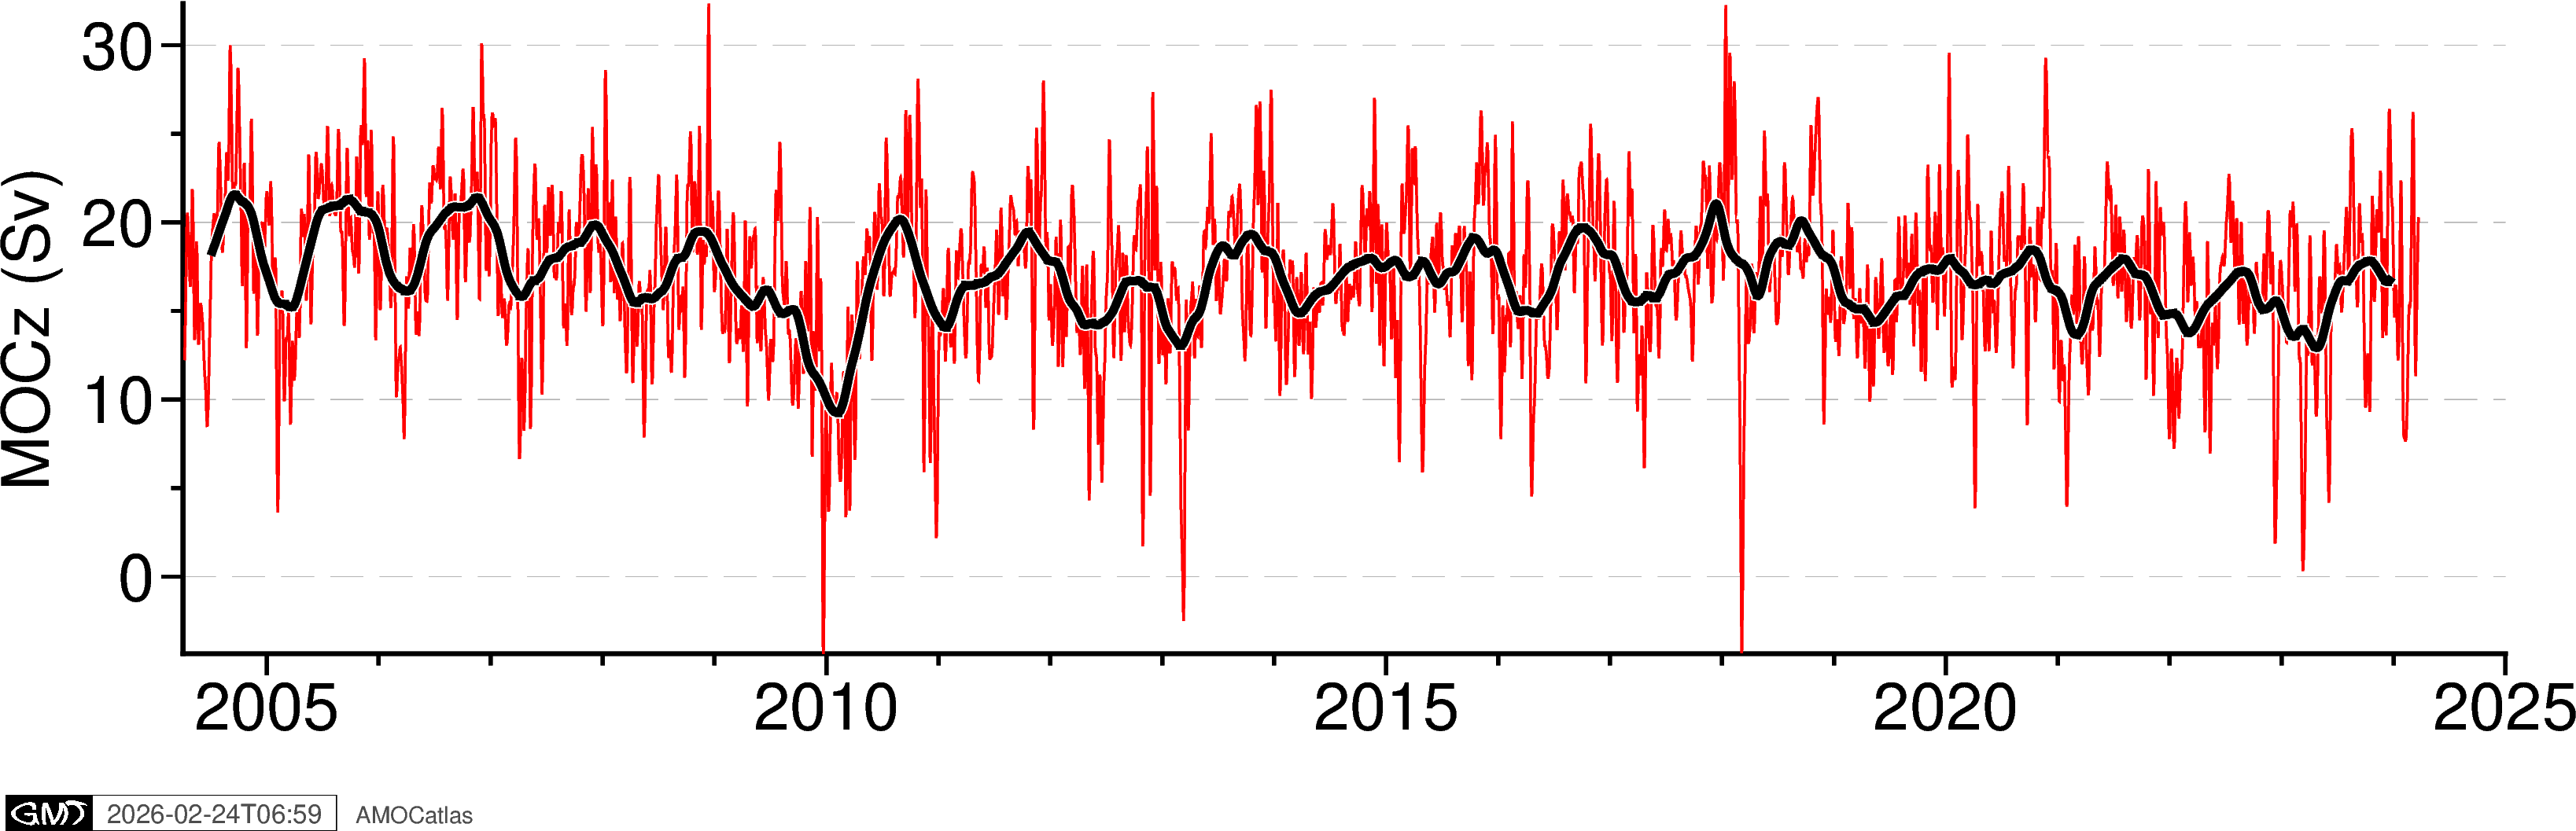

,time,time_num,moc
0,2004-04-06,2004.262295,0.650513
1,2004-04-16,2004.289617,1.470669
2,2004-04-26,2004.316940,1.276393
3,2004-05-06,2004.344262,1.287819
4,2004-05-16,2004.371585,1.267948
...,...,...,...
725,2024-02-11,2024.112022,0.498629
726,2024-02-21,2024.139344,1.033724
727,2024-03-02,2024.166667,1.684482
728,2024-03-12,2024.193989,1.001111


In [ ]:
filter_params = {"window_months": 6, "samples_per_day": 2, "alpha": 0.5}
rapid_filt = tools.apply_tukey_filter(rapid_df, column="moc", **filter_params)
fig_rapid = plotters.plot_moc_timeseries_pygmt(rapid_filt, label="MOCz (Sv)")
fig_rapid.show()
mht_df

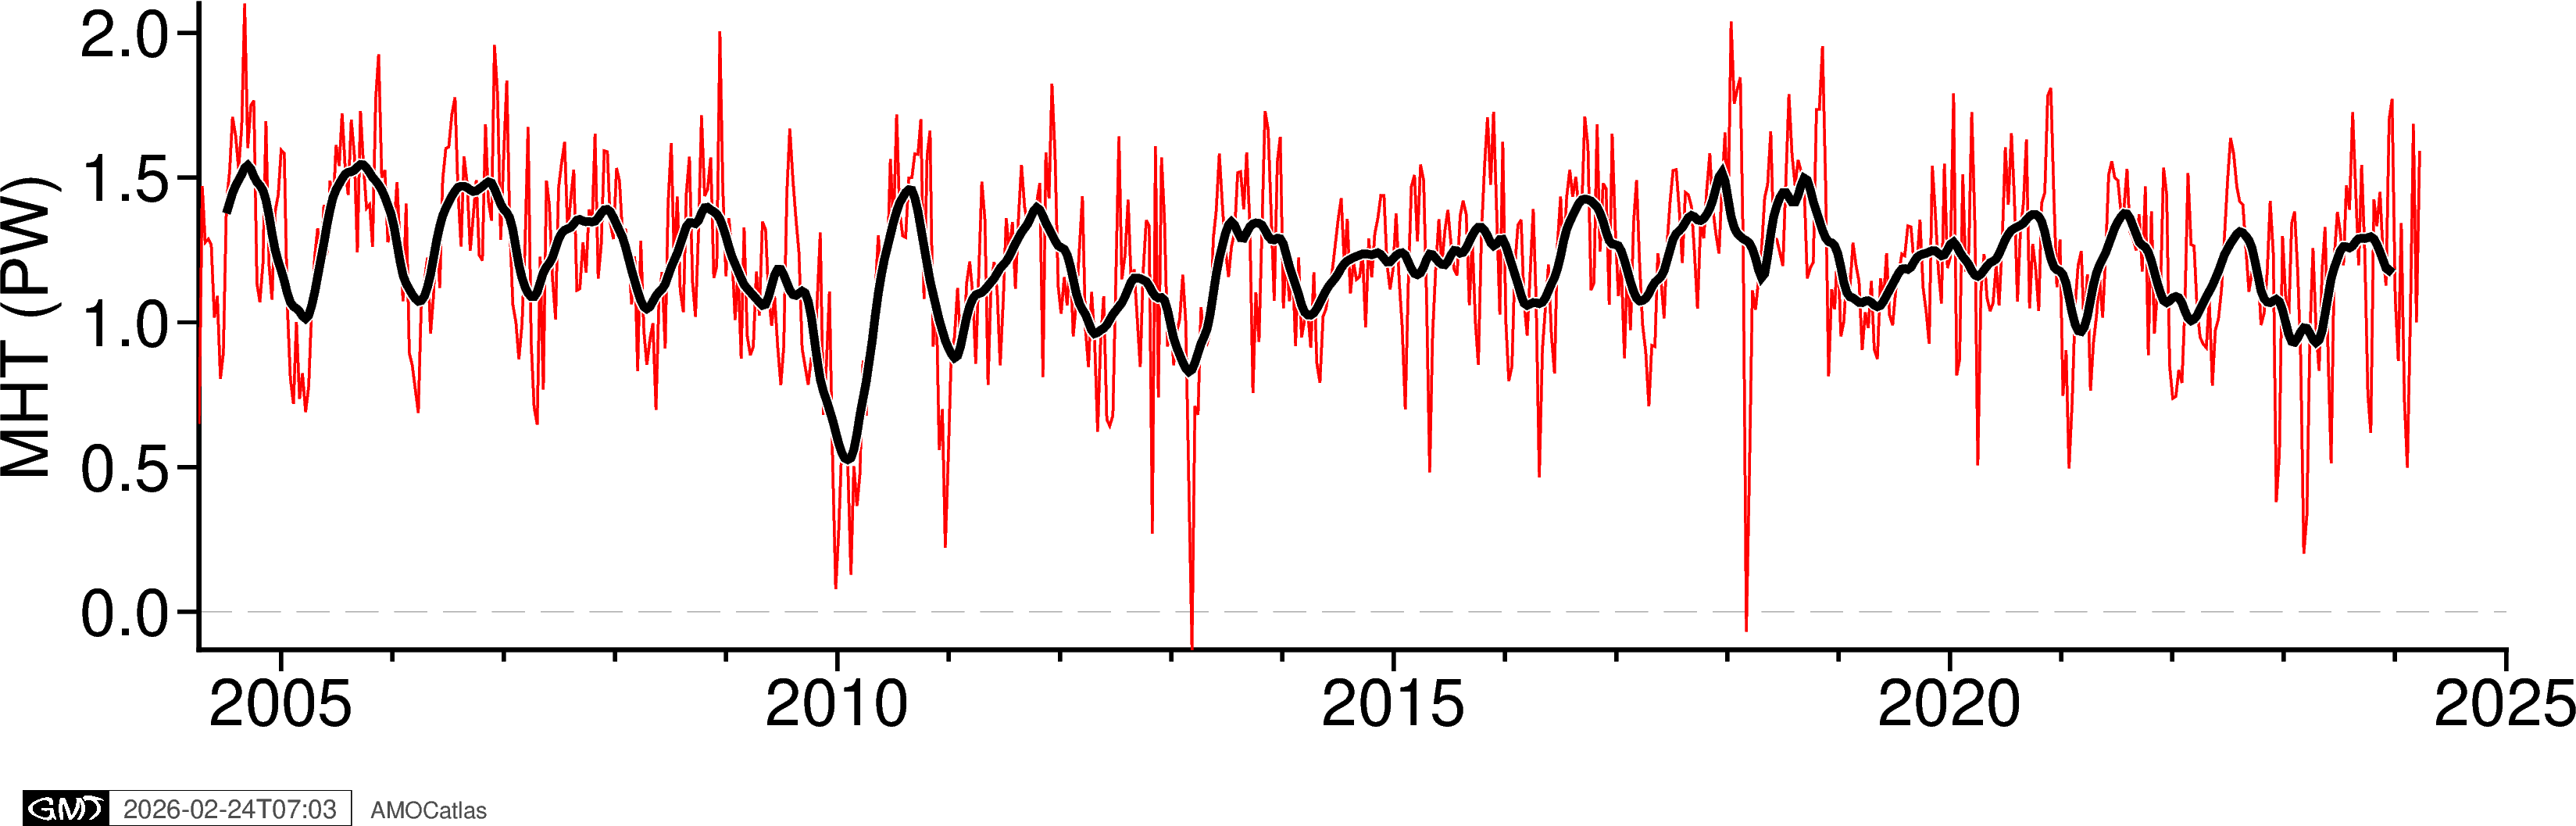

Mean MHT: 1.206 PW
Mean MOC: 16.977 Sv


In [ ]:
filter_params = {"window_months": 6, "samples_per_day": 1 / 10, "alpha": 0.5}
mocha_filt = tools.apply_tukey_filter(mht_df, column="moc", **filter_params)
fig_mocha = plotters.plot_moc_timeseries_pygmt(mocha_filt, label="MHT (PW)")
fig_mocha.show()
mht_mean = mht_df["moc"].mean()
print(f"Mean MHT: {mht_mean:.3f} PW")

mht_mean = rapid_df["moc"].mean()
print(f"Mean MOC: {mht_mean:.3f} Sv")

## 5. Single Array Time Series Plots

Create individual time series plots for each array.

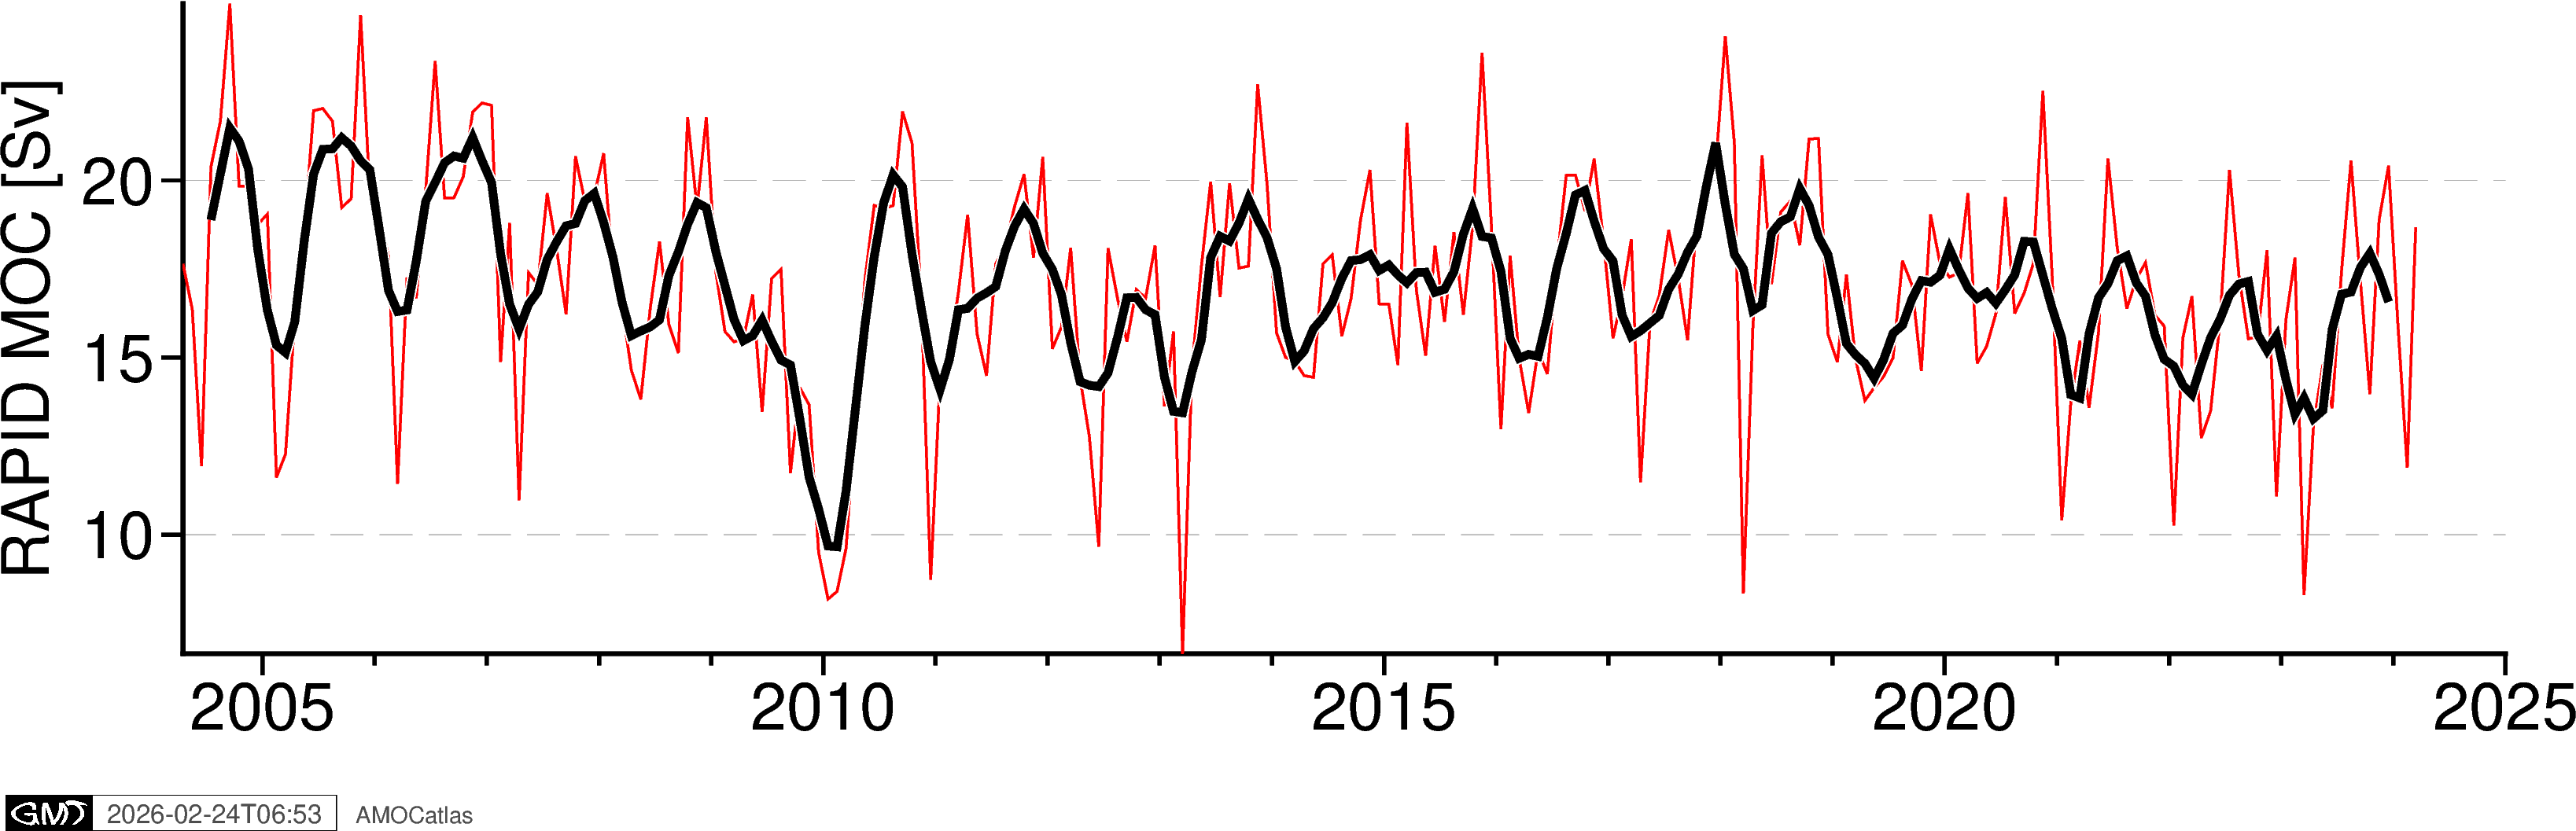

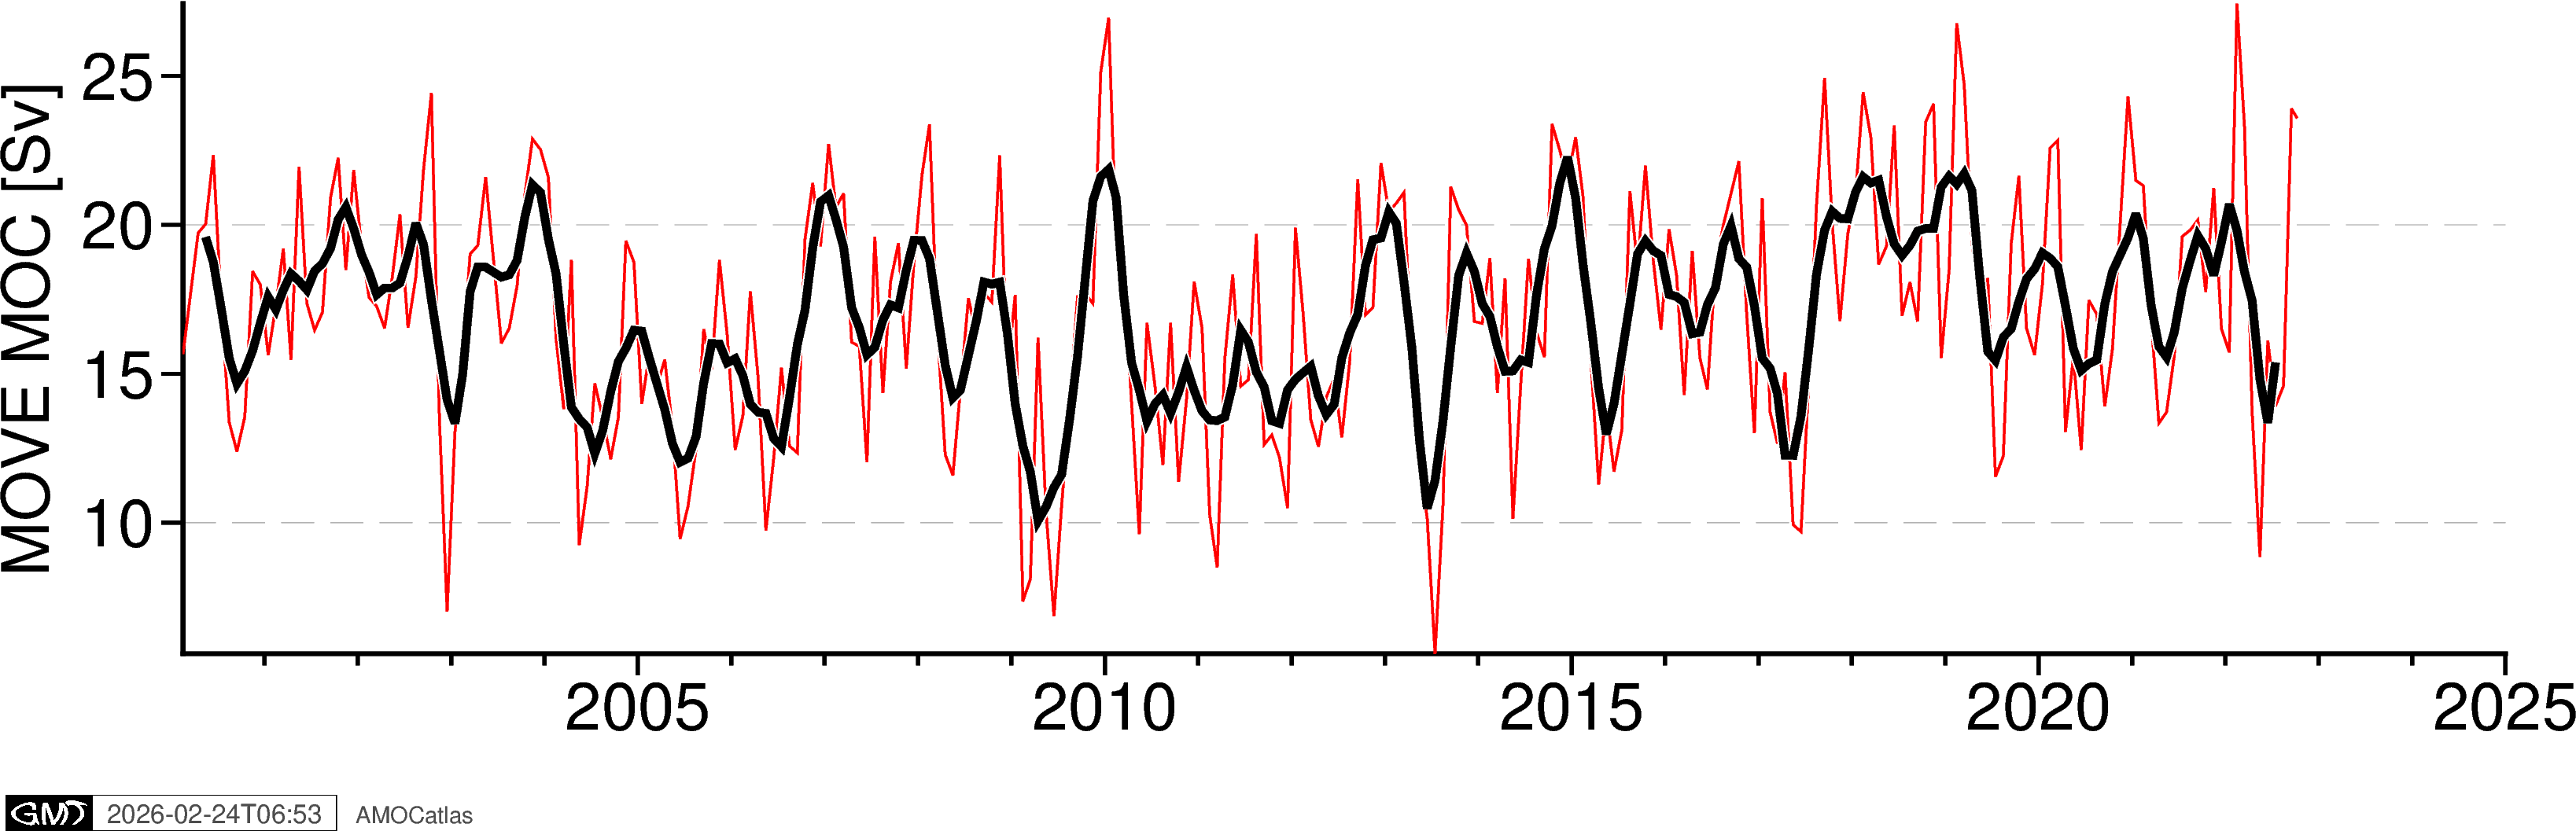

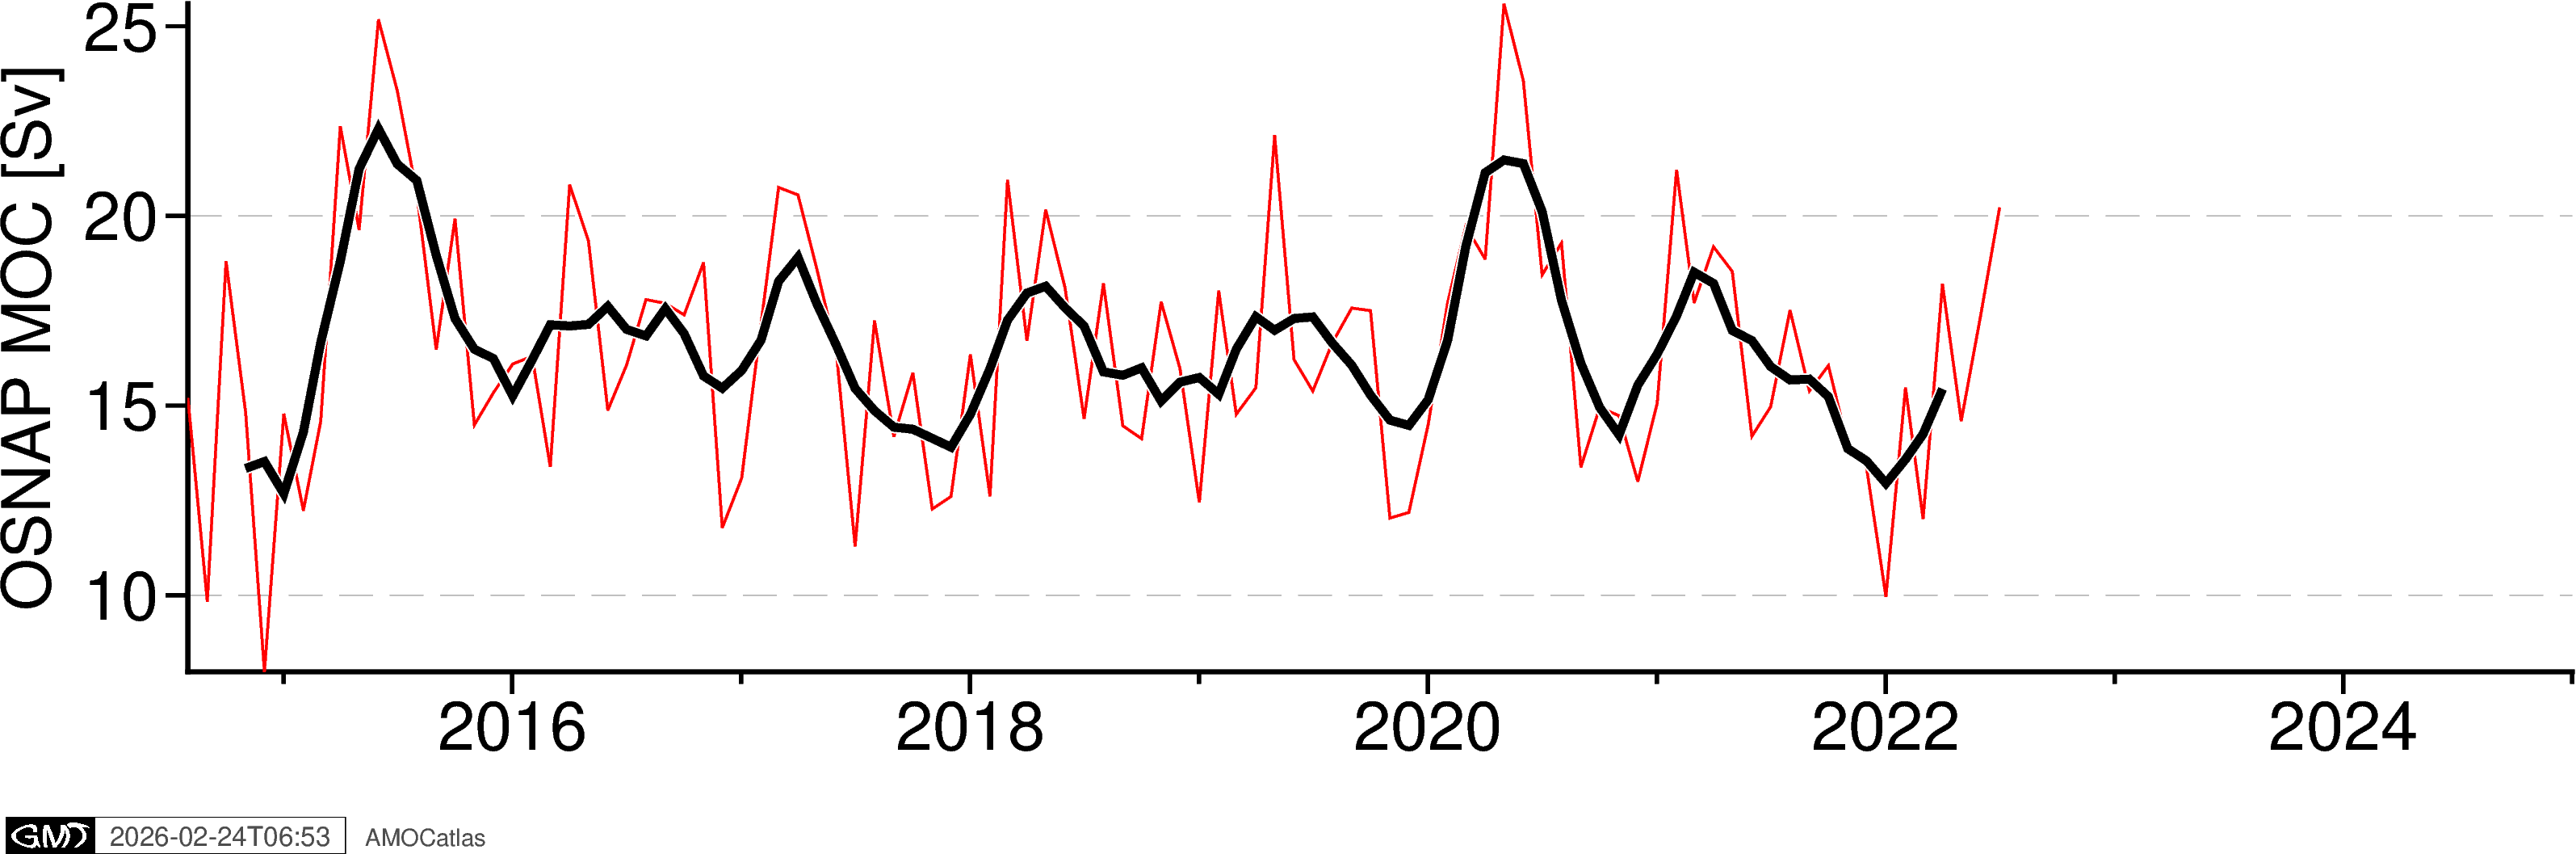

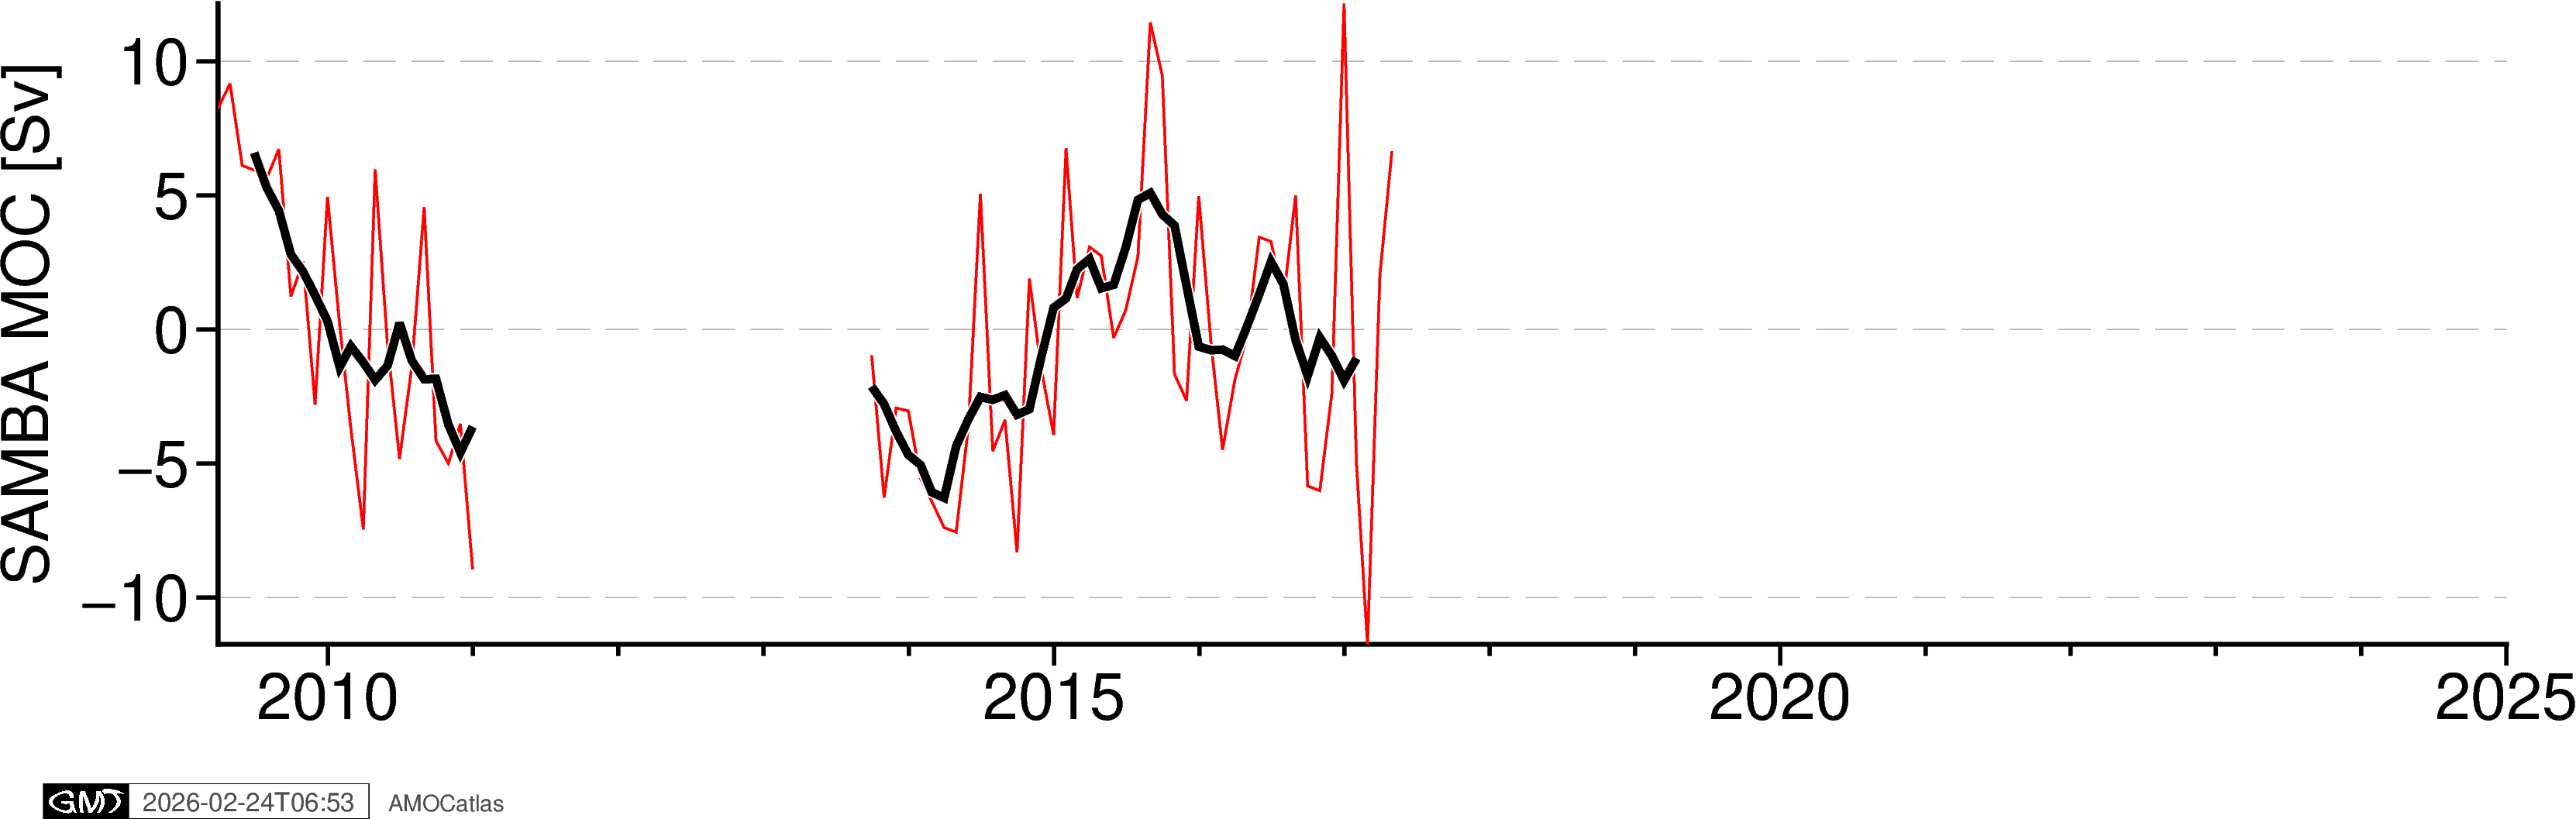

In [ ]:
# Individual time series plots
try:
    fig_rapid = plotters.plot_moc_timeseries_pygmt(
        rapid_filtered, label="RAPID MOC [Sv]"
    )
    fig_rapid.show()

    fig_move = plotters.plot_moc_timeseries_pygmt(move_filtered, label="MOVE MOC [Sv]")
    fig_move.show()

    fig_osnap = plotters.plot_moc_timeseries_pygmt(
        osnap_filtered, label="OSNAP MOC [Sv]"
    )
    fig_osnap.show()

    fig_samba = plotters.plot_moc_timeseries_pygmt(
        samba_filtered, label="SAMBA MOC [Sv]"
    )
    fig_samba.show()

except ImportError as e:
    print(f"PyGMT not available: {e}")
    print("Install with: pip install pygmt")

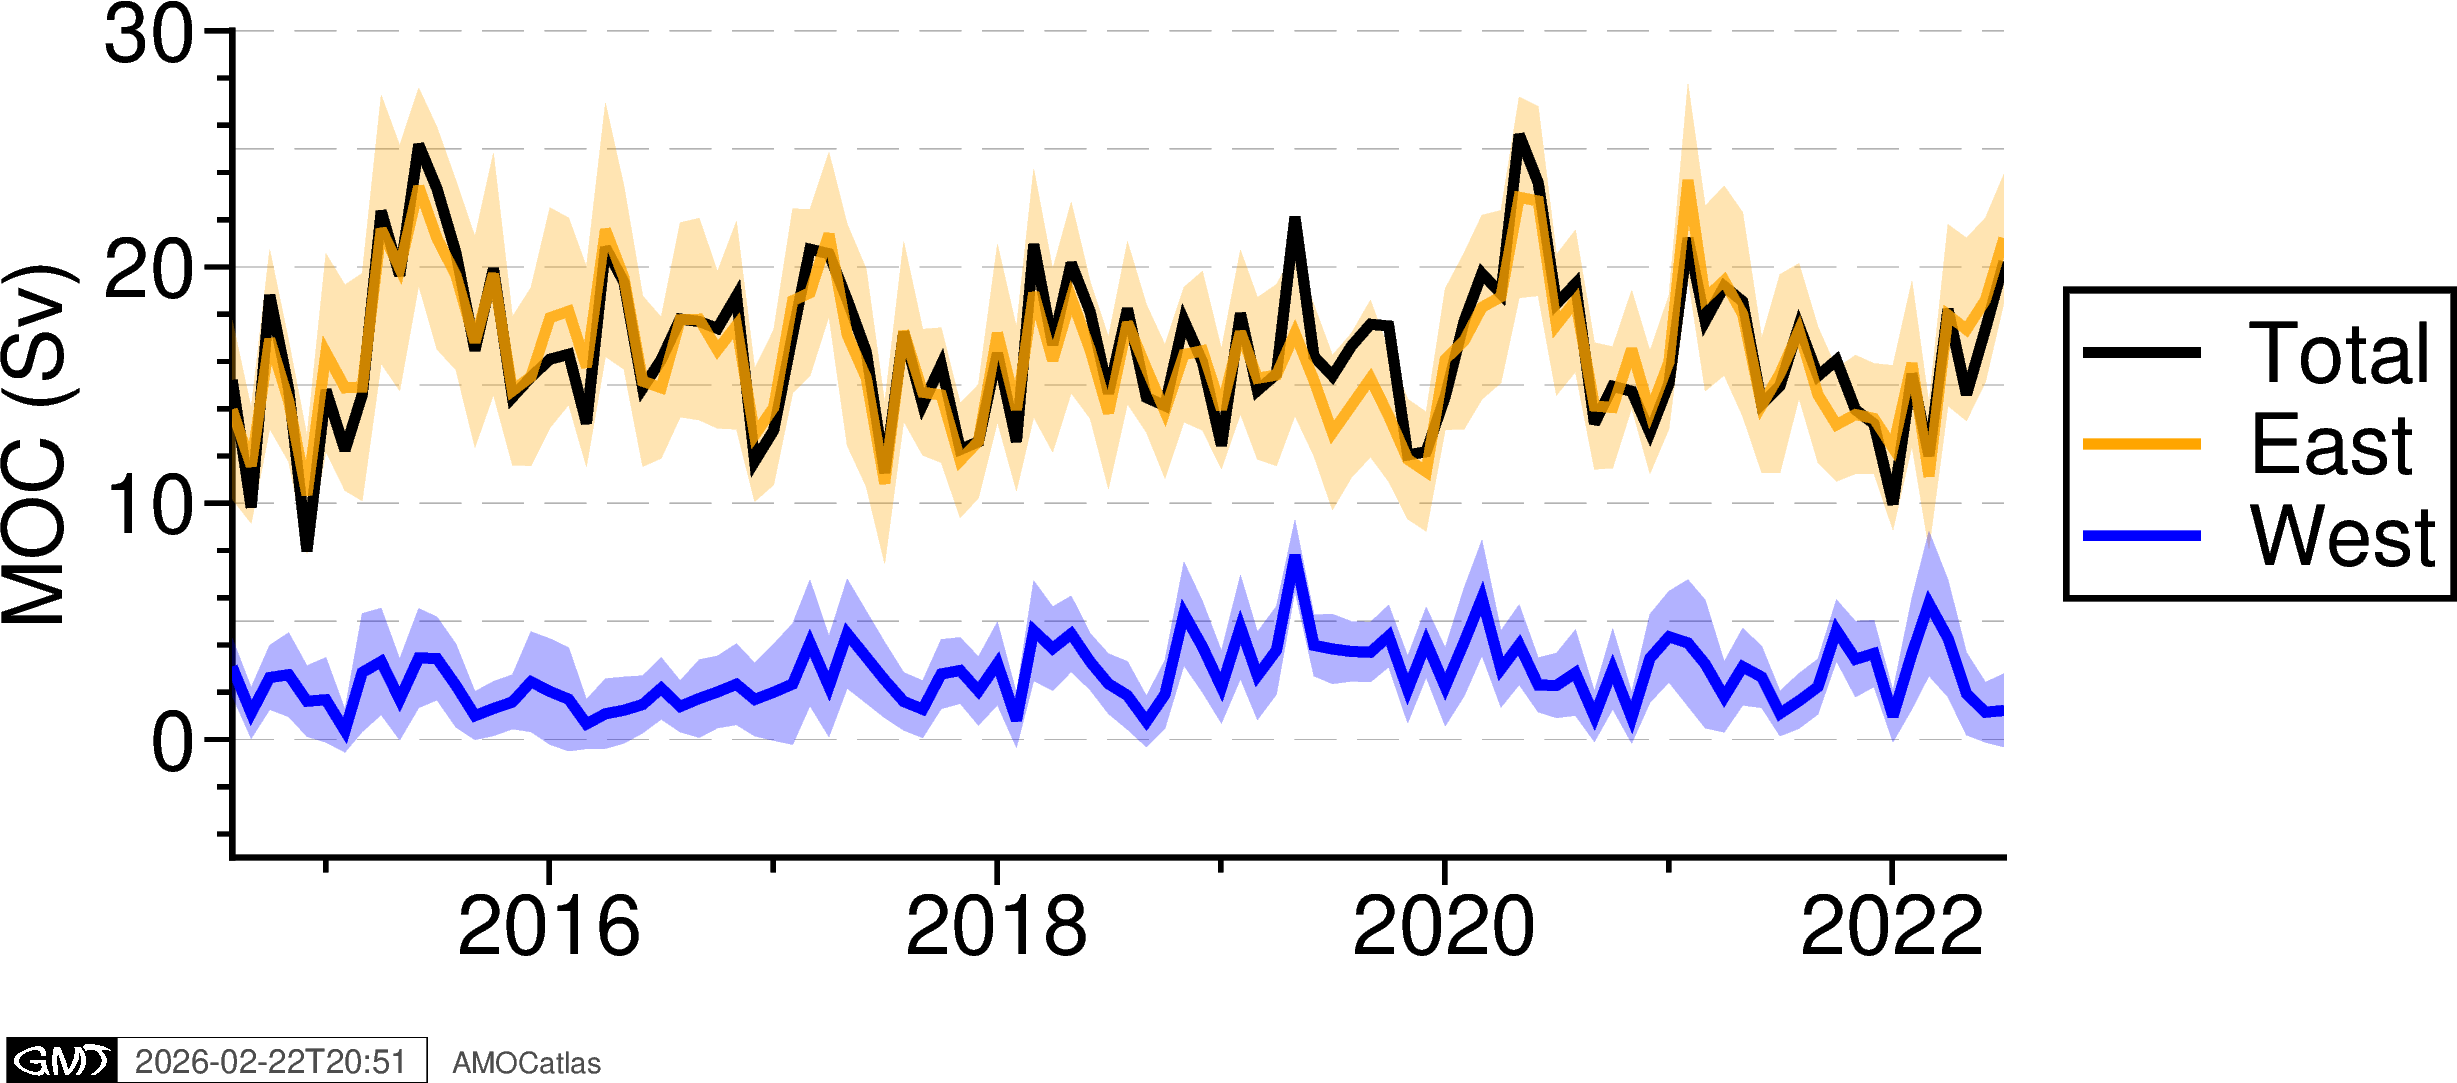

In [ ]:
# OSNAP components plot with error bands
try:
    # Extract OSNAP component data
    ds = osnap_std
    osnap_components = tools.extract_time_and_time_num(ds)

    # Add all OSNAP variables
    for var in [
        "MOC_SIGMA0",
        "MOC_SIGMA0_ERR",
        "MOC_EAST_SIGMA0",
        "MOC_EAST_SIGMA0_ERR",
        "MOC_WEST_SIGMA0",
        "MOC_WEST_SIGMA0_ERR",
    ]:
        osnap_components[var] = ds[var].values

    fig_osnap_comp = plotters.plot_osnap_components_pygmt(osnap_components)
    fig_osnap_comp.show()

    # Optional: save high-resolution version
    # fig_path = os.path.join(figures_dir, "osnap_components.png")
    # fig_osnap_comp.savefig(fig_path, dpi=300, transparent=True)
    # print(f"✓ Saved: {fig_path}")

except ImportError as e:
    print(f"PyGMT not available: {e}")

## 6. RAPID components plot

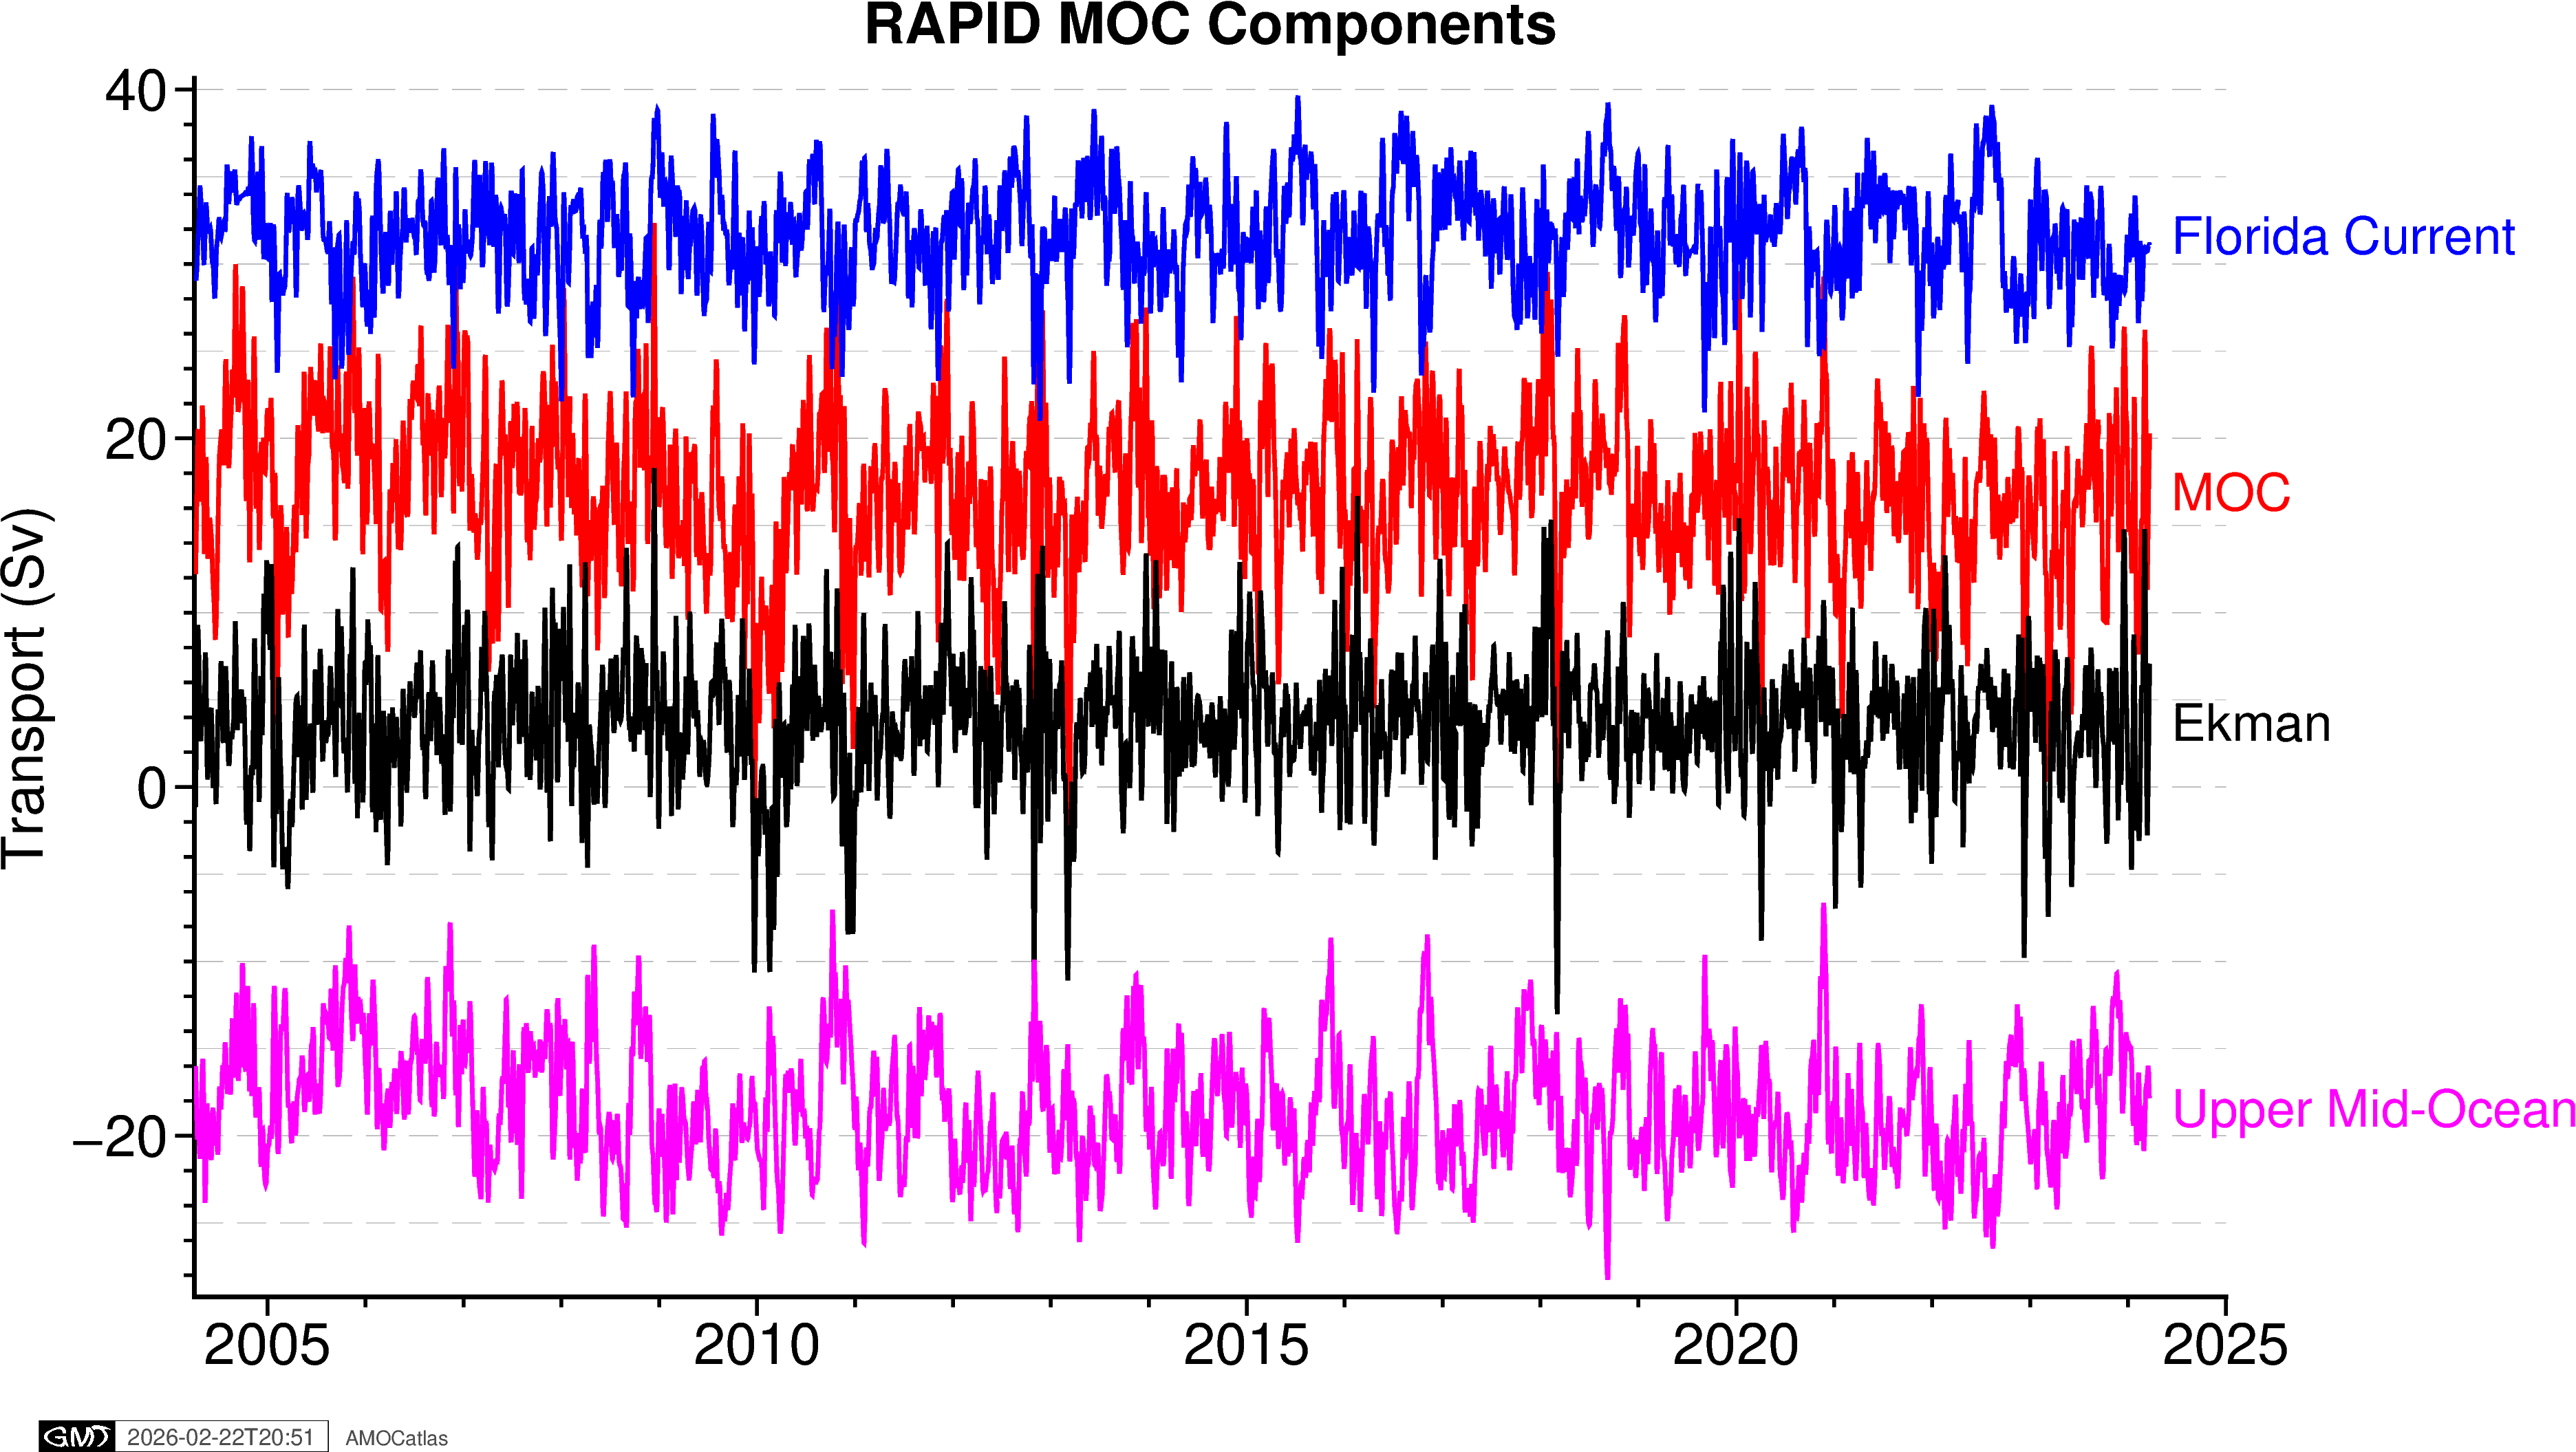

In [ ]:
# RAPID components plot
try:
    # Extract RAPID component data
    ds = rapid_std[0]
    rapid_components = tools.extract_time_and_time_num(ds)

    # Add transport components
    rapid_components["moc_mar_hc10"] = ds["MOC"].values
    rapid_components["t_gs10"] = ds["TRANS_FC"].values  # Florida Current
    rapid_components["t_ek10"] = ds["TRANS_EKMAN"].values  # Ekman
    rapid_components["t_umo10"] = ds["TRANS_UMO"].values  # Upper Mid-Ocean

    fig_rapid_comp = plotters.plot_rapid_components_pygmt(rapid_components)
    fig_rapid_comp.show()

except ImportError as e:
    print(f"PyGMT not available: {e}")

## 7. Multi-array comparison plot - original data
try:
    fig_multi = plotters.plot_all_moc_pygmt(
        osnap_filtered, rapid_filtered, move_filtered, samba_filtered,
        filtered=False
    )
    fig_multi.show()
    
    # Save high-resolution version
    fig_path = os.path.join(figures_dir, "amoc_multi_array.png")
    fig_multi.savefig(fig_path, dpi=300, transparent=True)
    print(f"✓ Saved: {fig_path}")
    
except ImportError as e:
    print(f"PyGMT not available: {e}")

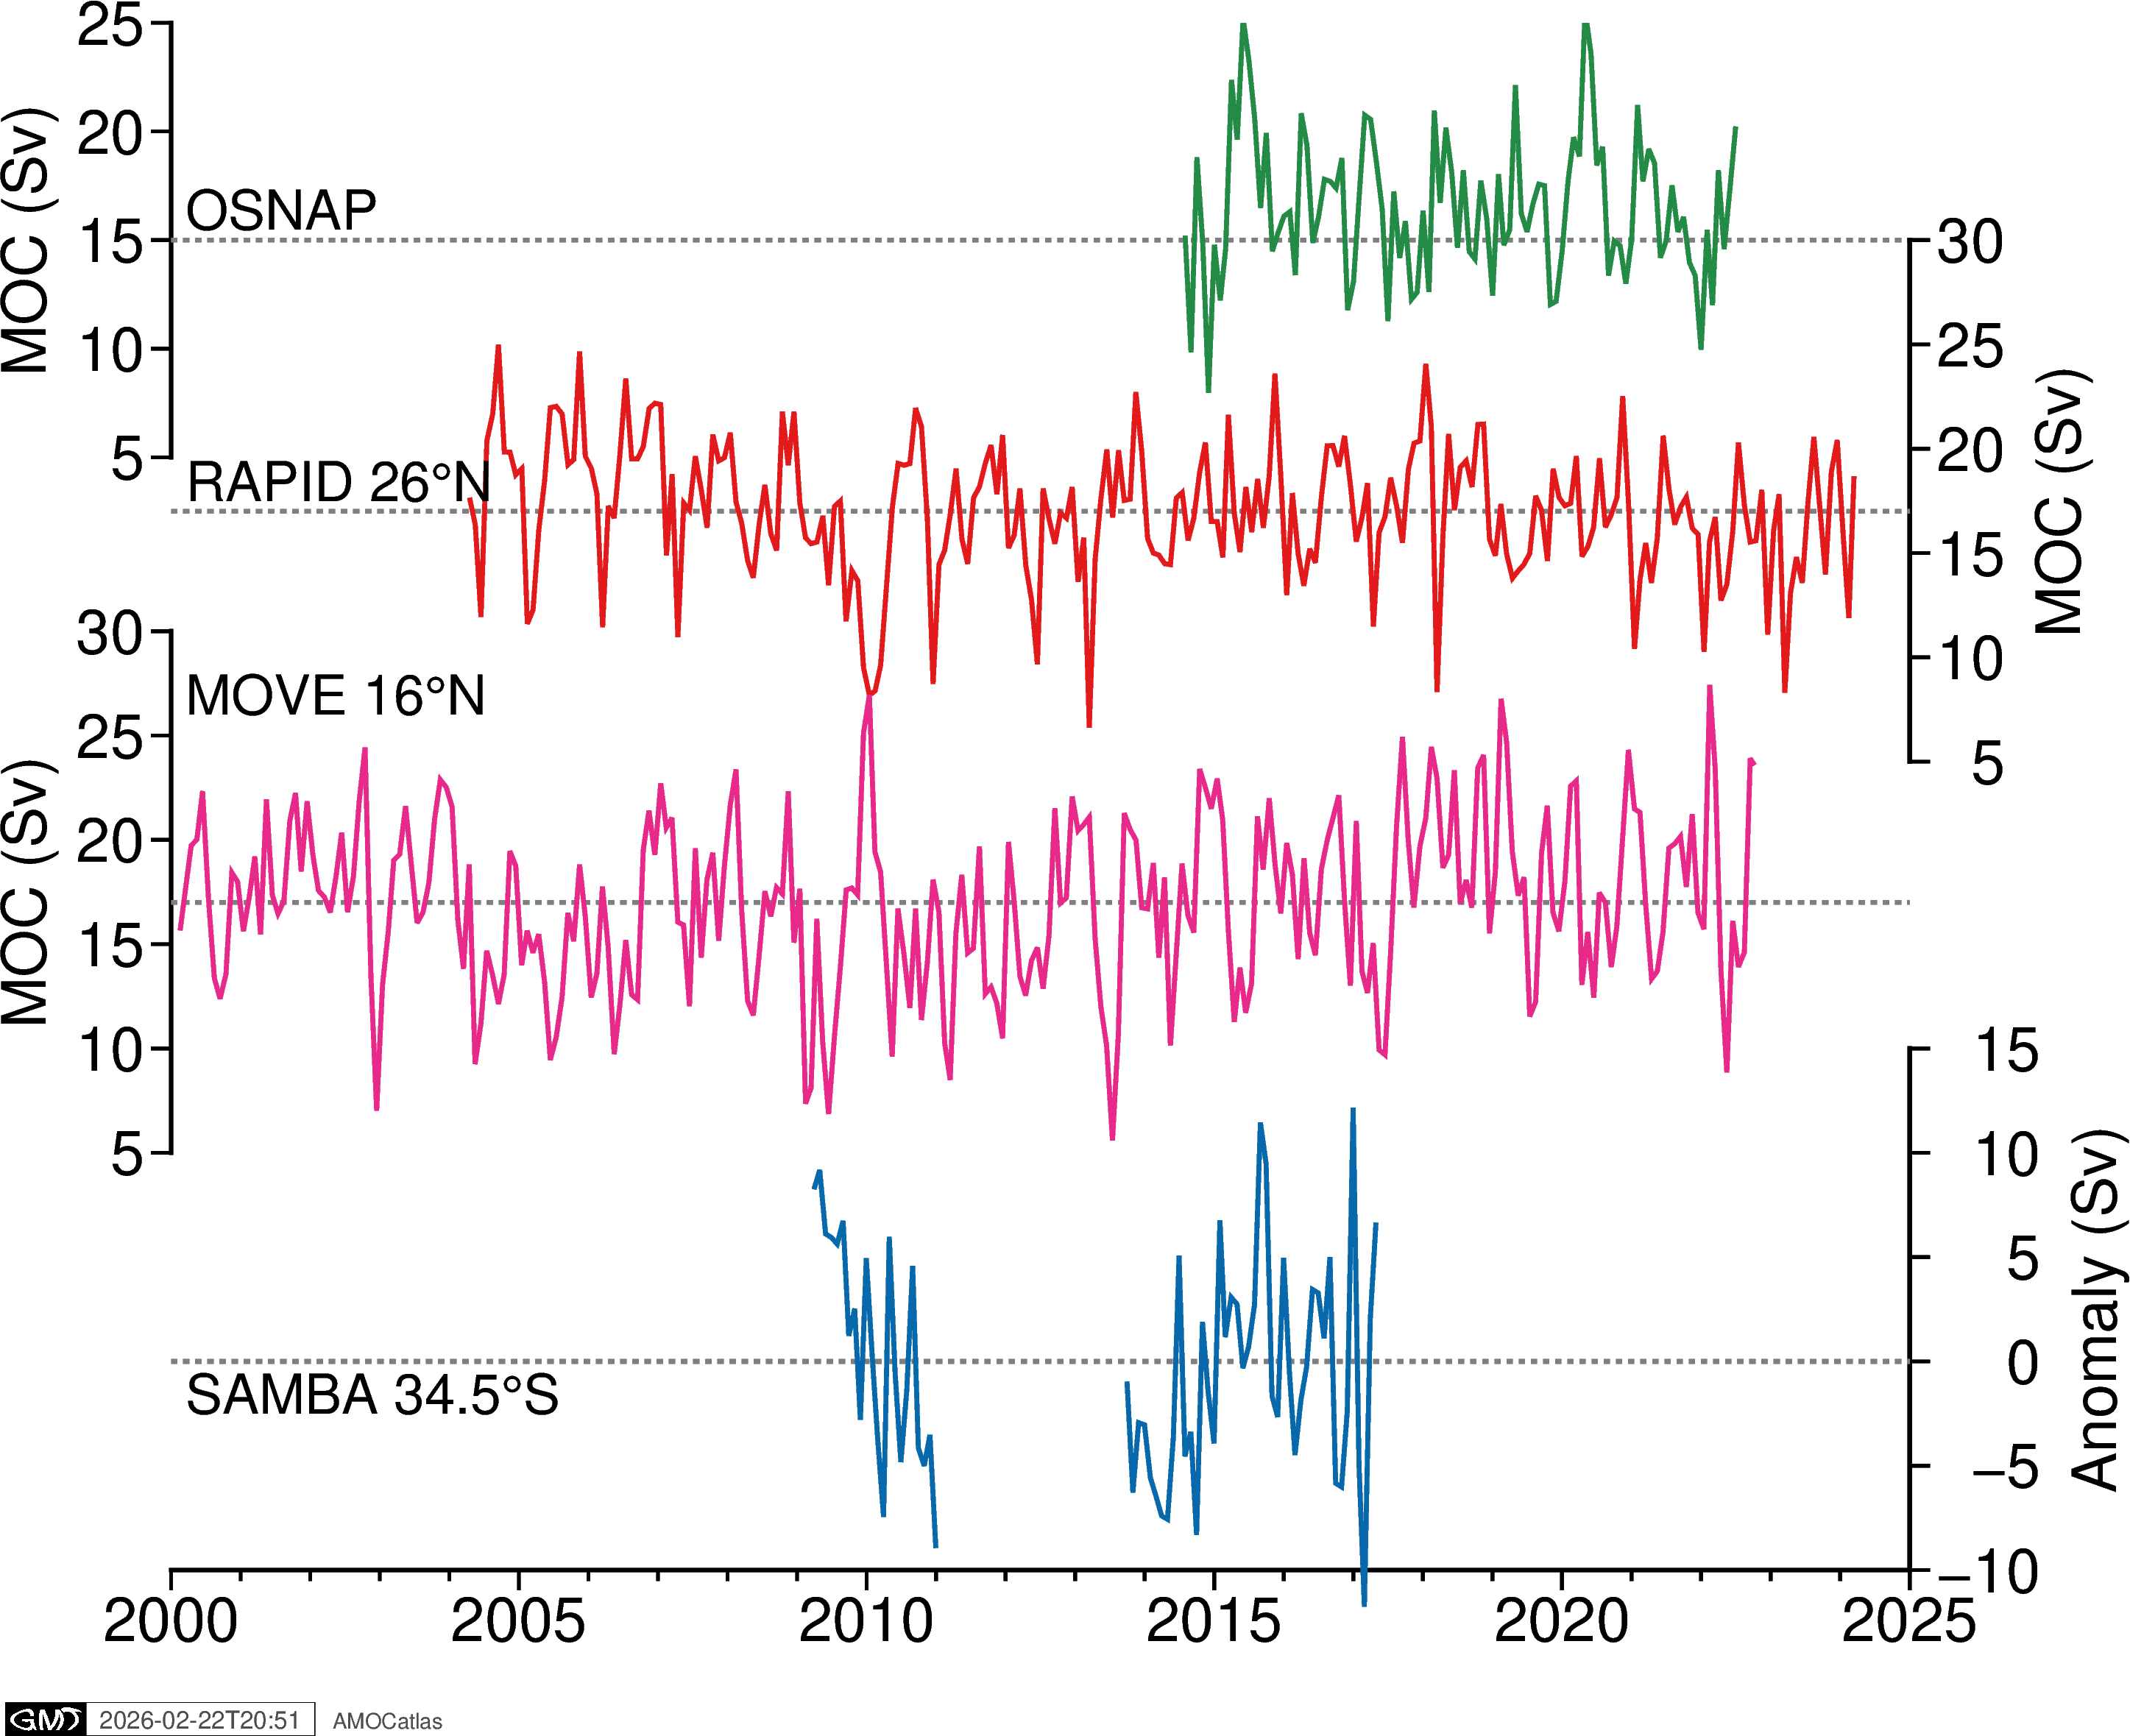

✓ Saved: ../docs/source/_static/paperfigs/amoc_multi_array.png


In [ ]:
# Multi-array comparison plot - filtered data
try:
    fig_multi_filt = plotters.plot_all_moc_pygmt(
        osnap_binned, rapid_binned, move_binned, samba_binned, filtered=False
    )
    fig_multi_filt.show()

    # Save high-resolution version
    fig_path = os.path.join(figures_dir, "amoc_multi_array.png")
    fig_multi_filt.savefig(fig_path, dpi=300, transparent=True)
    print(f"✓ Saved: {fig_path}")

except ImportError as e:
    print(f"PyGMT not available: {e}")

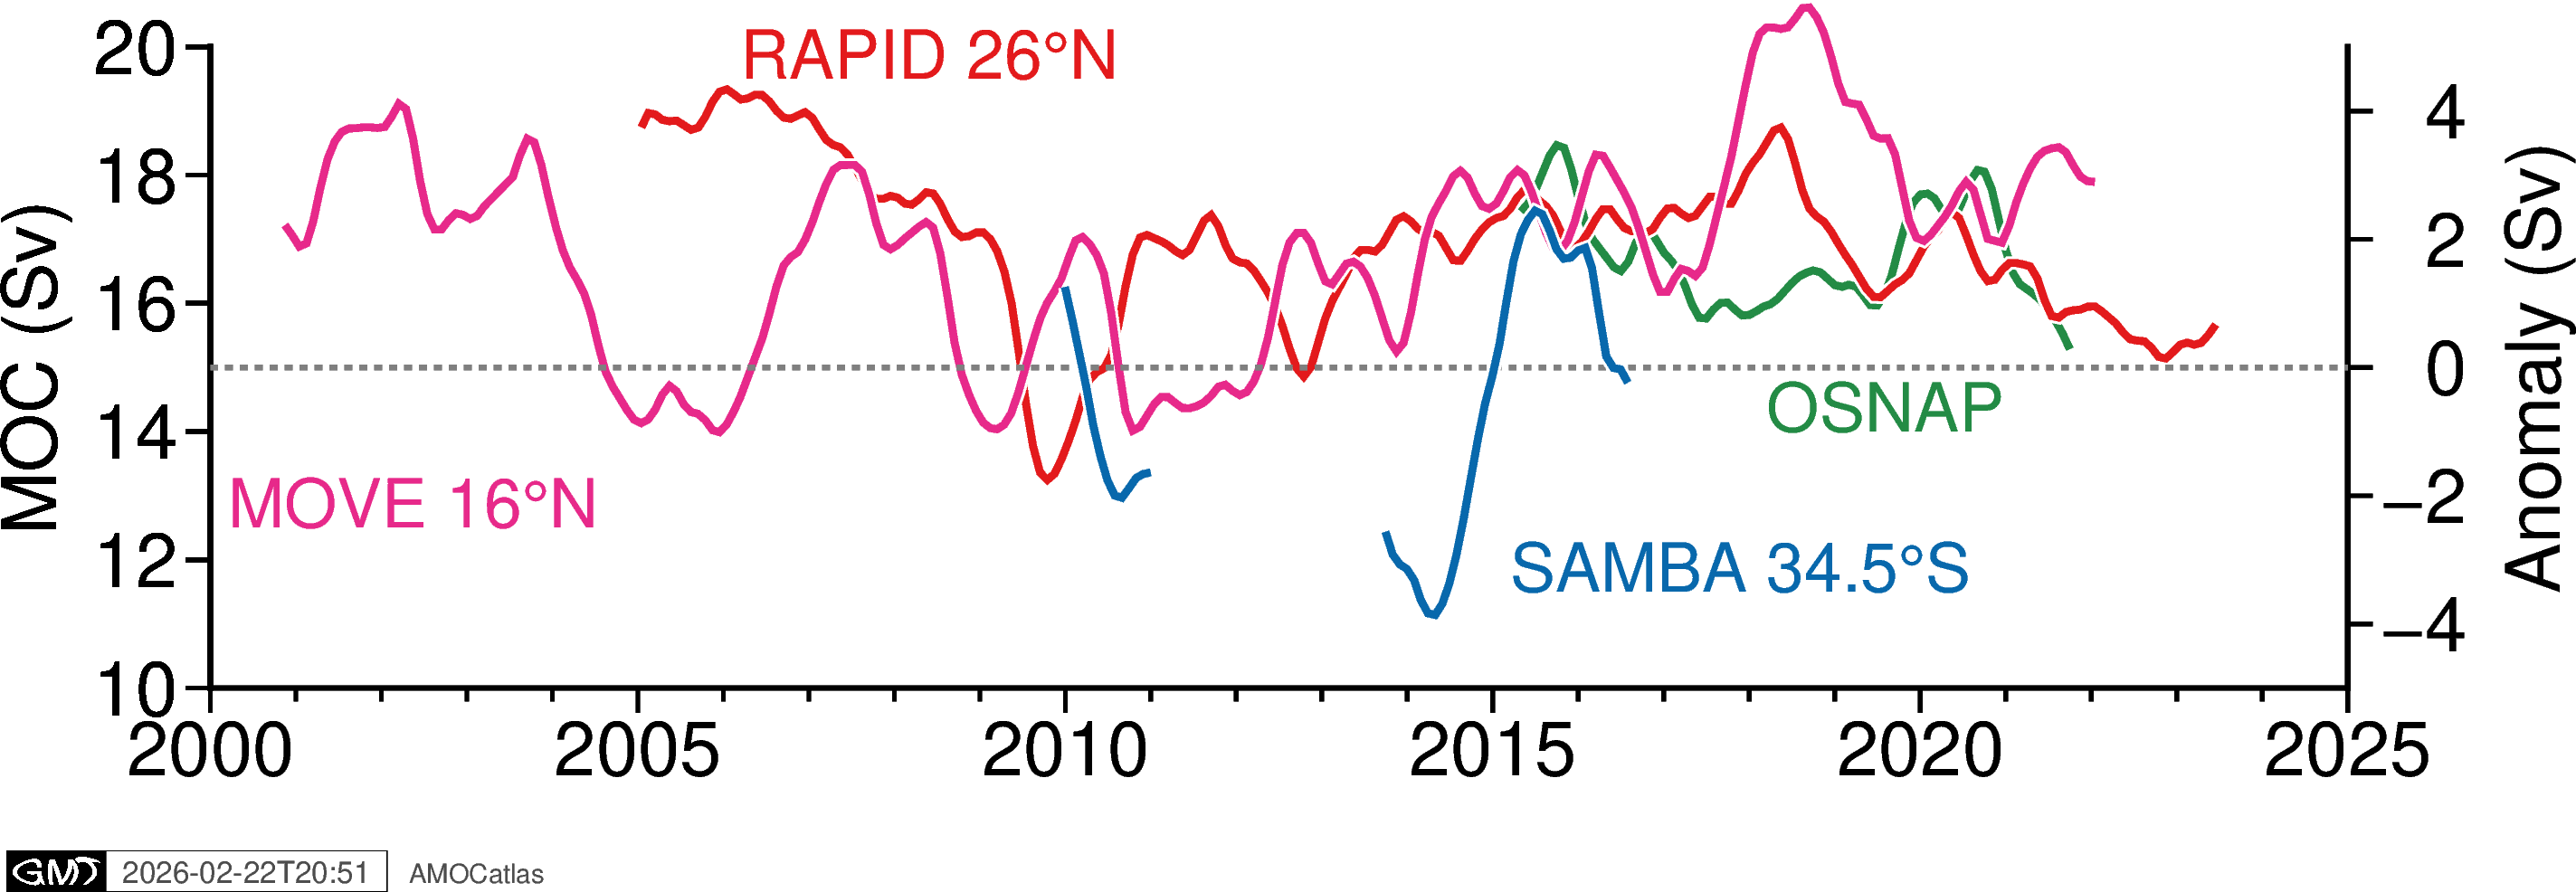

In [ ]:
# Or overlaid, with SAMBA offset because it's an anomaly

fig_overlaid = plotters.plot_all_moc_overlaid_pygmt(
    osnap_filtered, rapid_filtered, move_filtered, samba_filtered, filtered=True
)

fig_overlaid.show()

In [ ]:
## 8. Historical AMOC estimates from Bryden et al. 2005


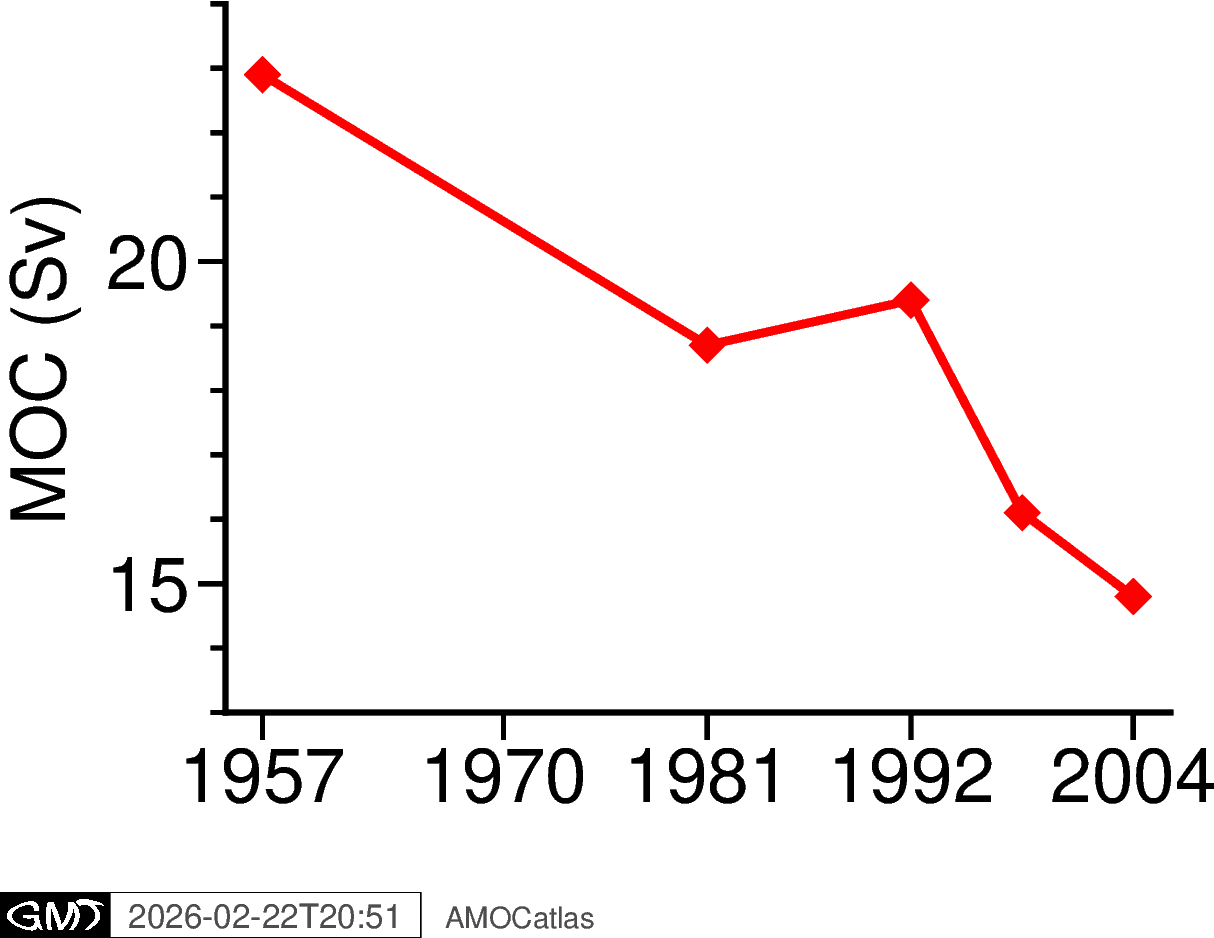

✓ Saved: ../docs/source/_static/paperfigs/bryden2005_amoc.png


In [ ]:
try:
    fig_bryden = plotters.plot_bryden2005_pygmt()
    fig_bryden.show()

    # Save high-resolution version
    fig_path = os.path.join(figures_dir, "bryden2005_amoc.png")
    fig_bryden.savefig(fig_path, dpi=300, transparent=True)
    print(f"✓ Saved: {fig_path}")

except ImportError as e:
    print(f"PyGMT not available: {e}")

## 9. Summary

This notebook demonstrates the streamlined workflow for creating publication-quality AMOC figures:

1. **Data Loading**: Using `read.rapid()` for consistent data access and standardisation
2. **Time Series Processing**: Converting to pandas with `tools.extract_time_and_time_num()`
3. **Gap Handling**: Using `tools.handle_samba_gaps()` to prevent plotting artifacts
4. **Filtering**: Applying Tukey filters with `tools.apply_tukey_filter()`
5. **Visualization**: Creating publication plots with `plotters.plot_*_pygmt()` functions

**Key Features:**
- Modular design using AMOCatlas functions
- Optional PyGMT dependency with graceful fallback
- Consistent styling across all plots
- Proper handling of temporal gaps in SAMBA data
- Historical context from Bryden et al. (2005)
- High-resolution export capability (saved to `docs/source/_static/paperfigs/`)
